=== Building Rust binary in release mode ===
Cargo build completed successfully.

MANUAL_TXS: scan,1 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 scan,1 scan,14 delta_scan,1
Running for table_type=linear with 1 repeats...
  - Trial 1/1
Running for table_type=chain with 1 repeats...
  - Trial 1/1
Running for table_type=heap with 1 repeats...
  - Trial 1/1
Running for table_type=partition with 1 repeats...
  - Trial 1/1


,idx,tx_id,tx_type,repair_type,table_type,duration_ms,count,read_ts
0,0,0,Insert,No Repair,linear,257.319515,500000.0,NaN
1,0,0,Insert,Read Repair,linear,263.121626,500000.0,NaN
2,0,0,Insert,Write Repair,linear,255.765540,500000.0,NaN
3,1,1,Scan,No Repair,linear,114.602383,NaN,1.0
4,1,1,Scan,Read Repair,linear,113.792977,NaN,1.0
...,...,...,...,...,...,...,...,...
175,13,13,Scan,Read Repair,partition,406.914272,NaN,14.0
176,13,13,Scan,Write Repair,partition,228.868313,NaN,14.0
177,14,14,DeltaScan,No Repair,partition,248.151470,NaN,1.0
178,14,14,DeltaScan,Read Repair,partition,245.557927,NaN,1.0


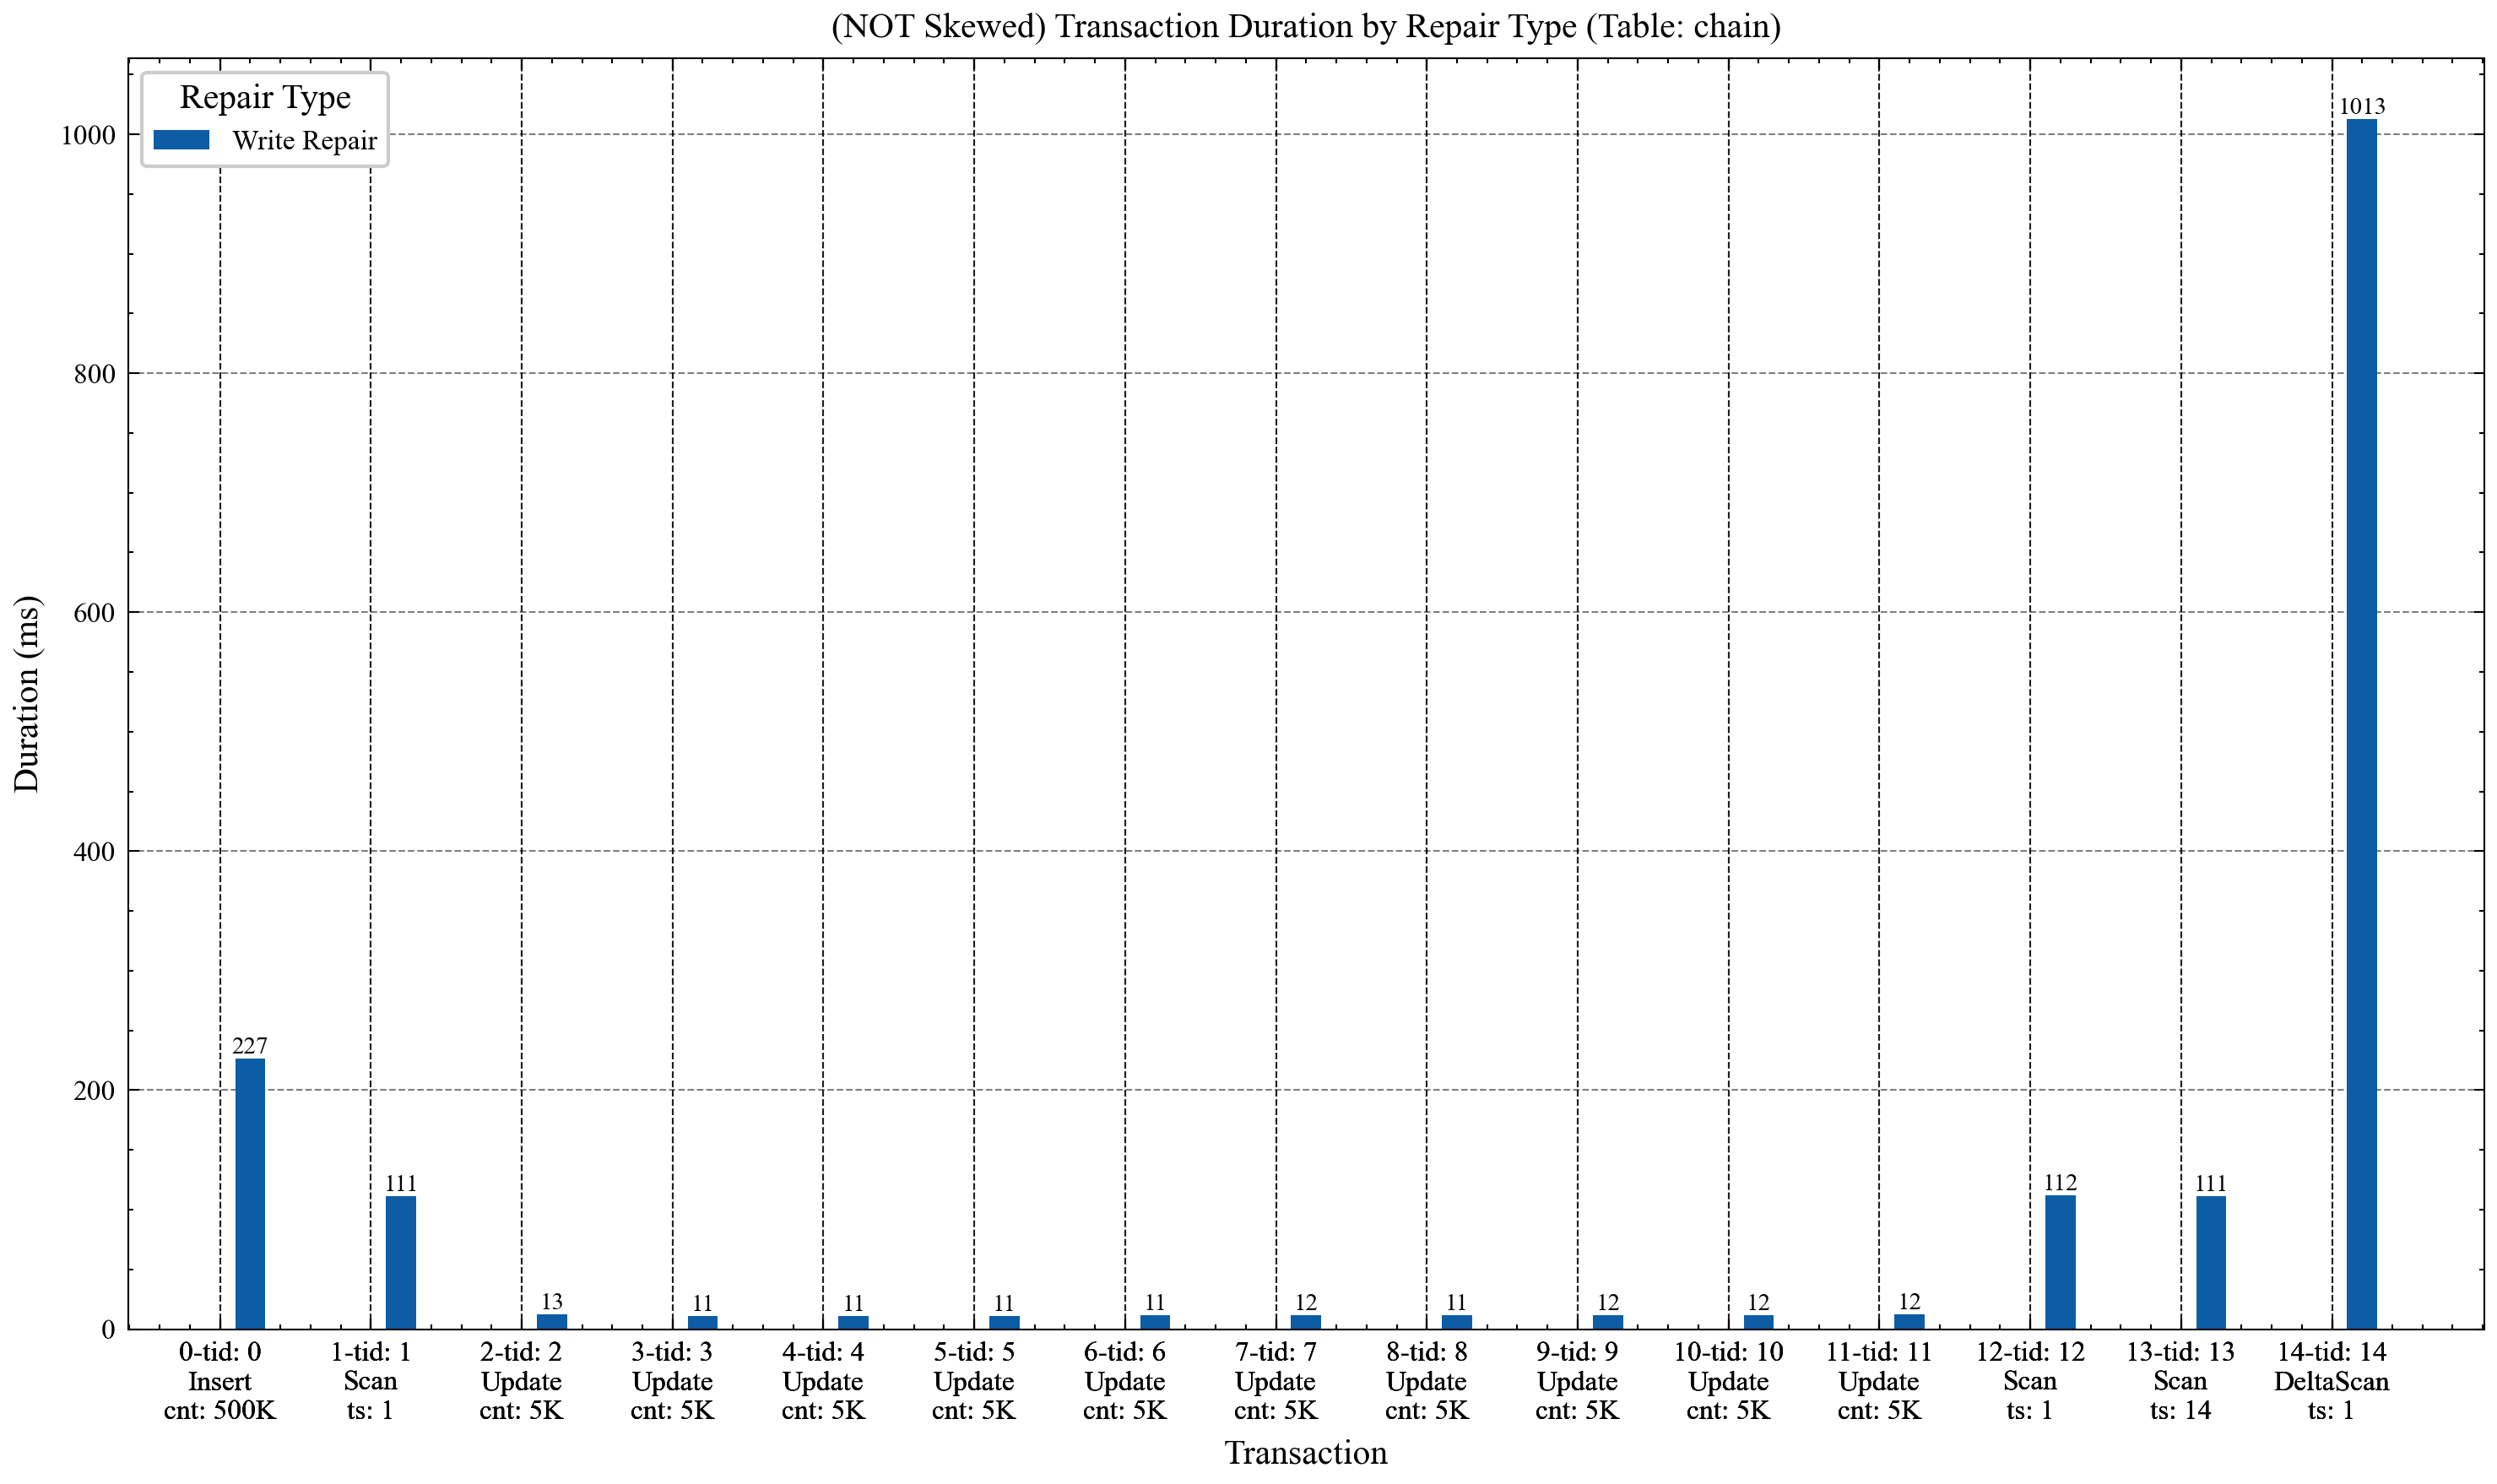

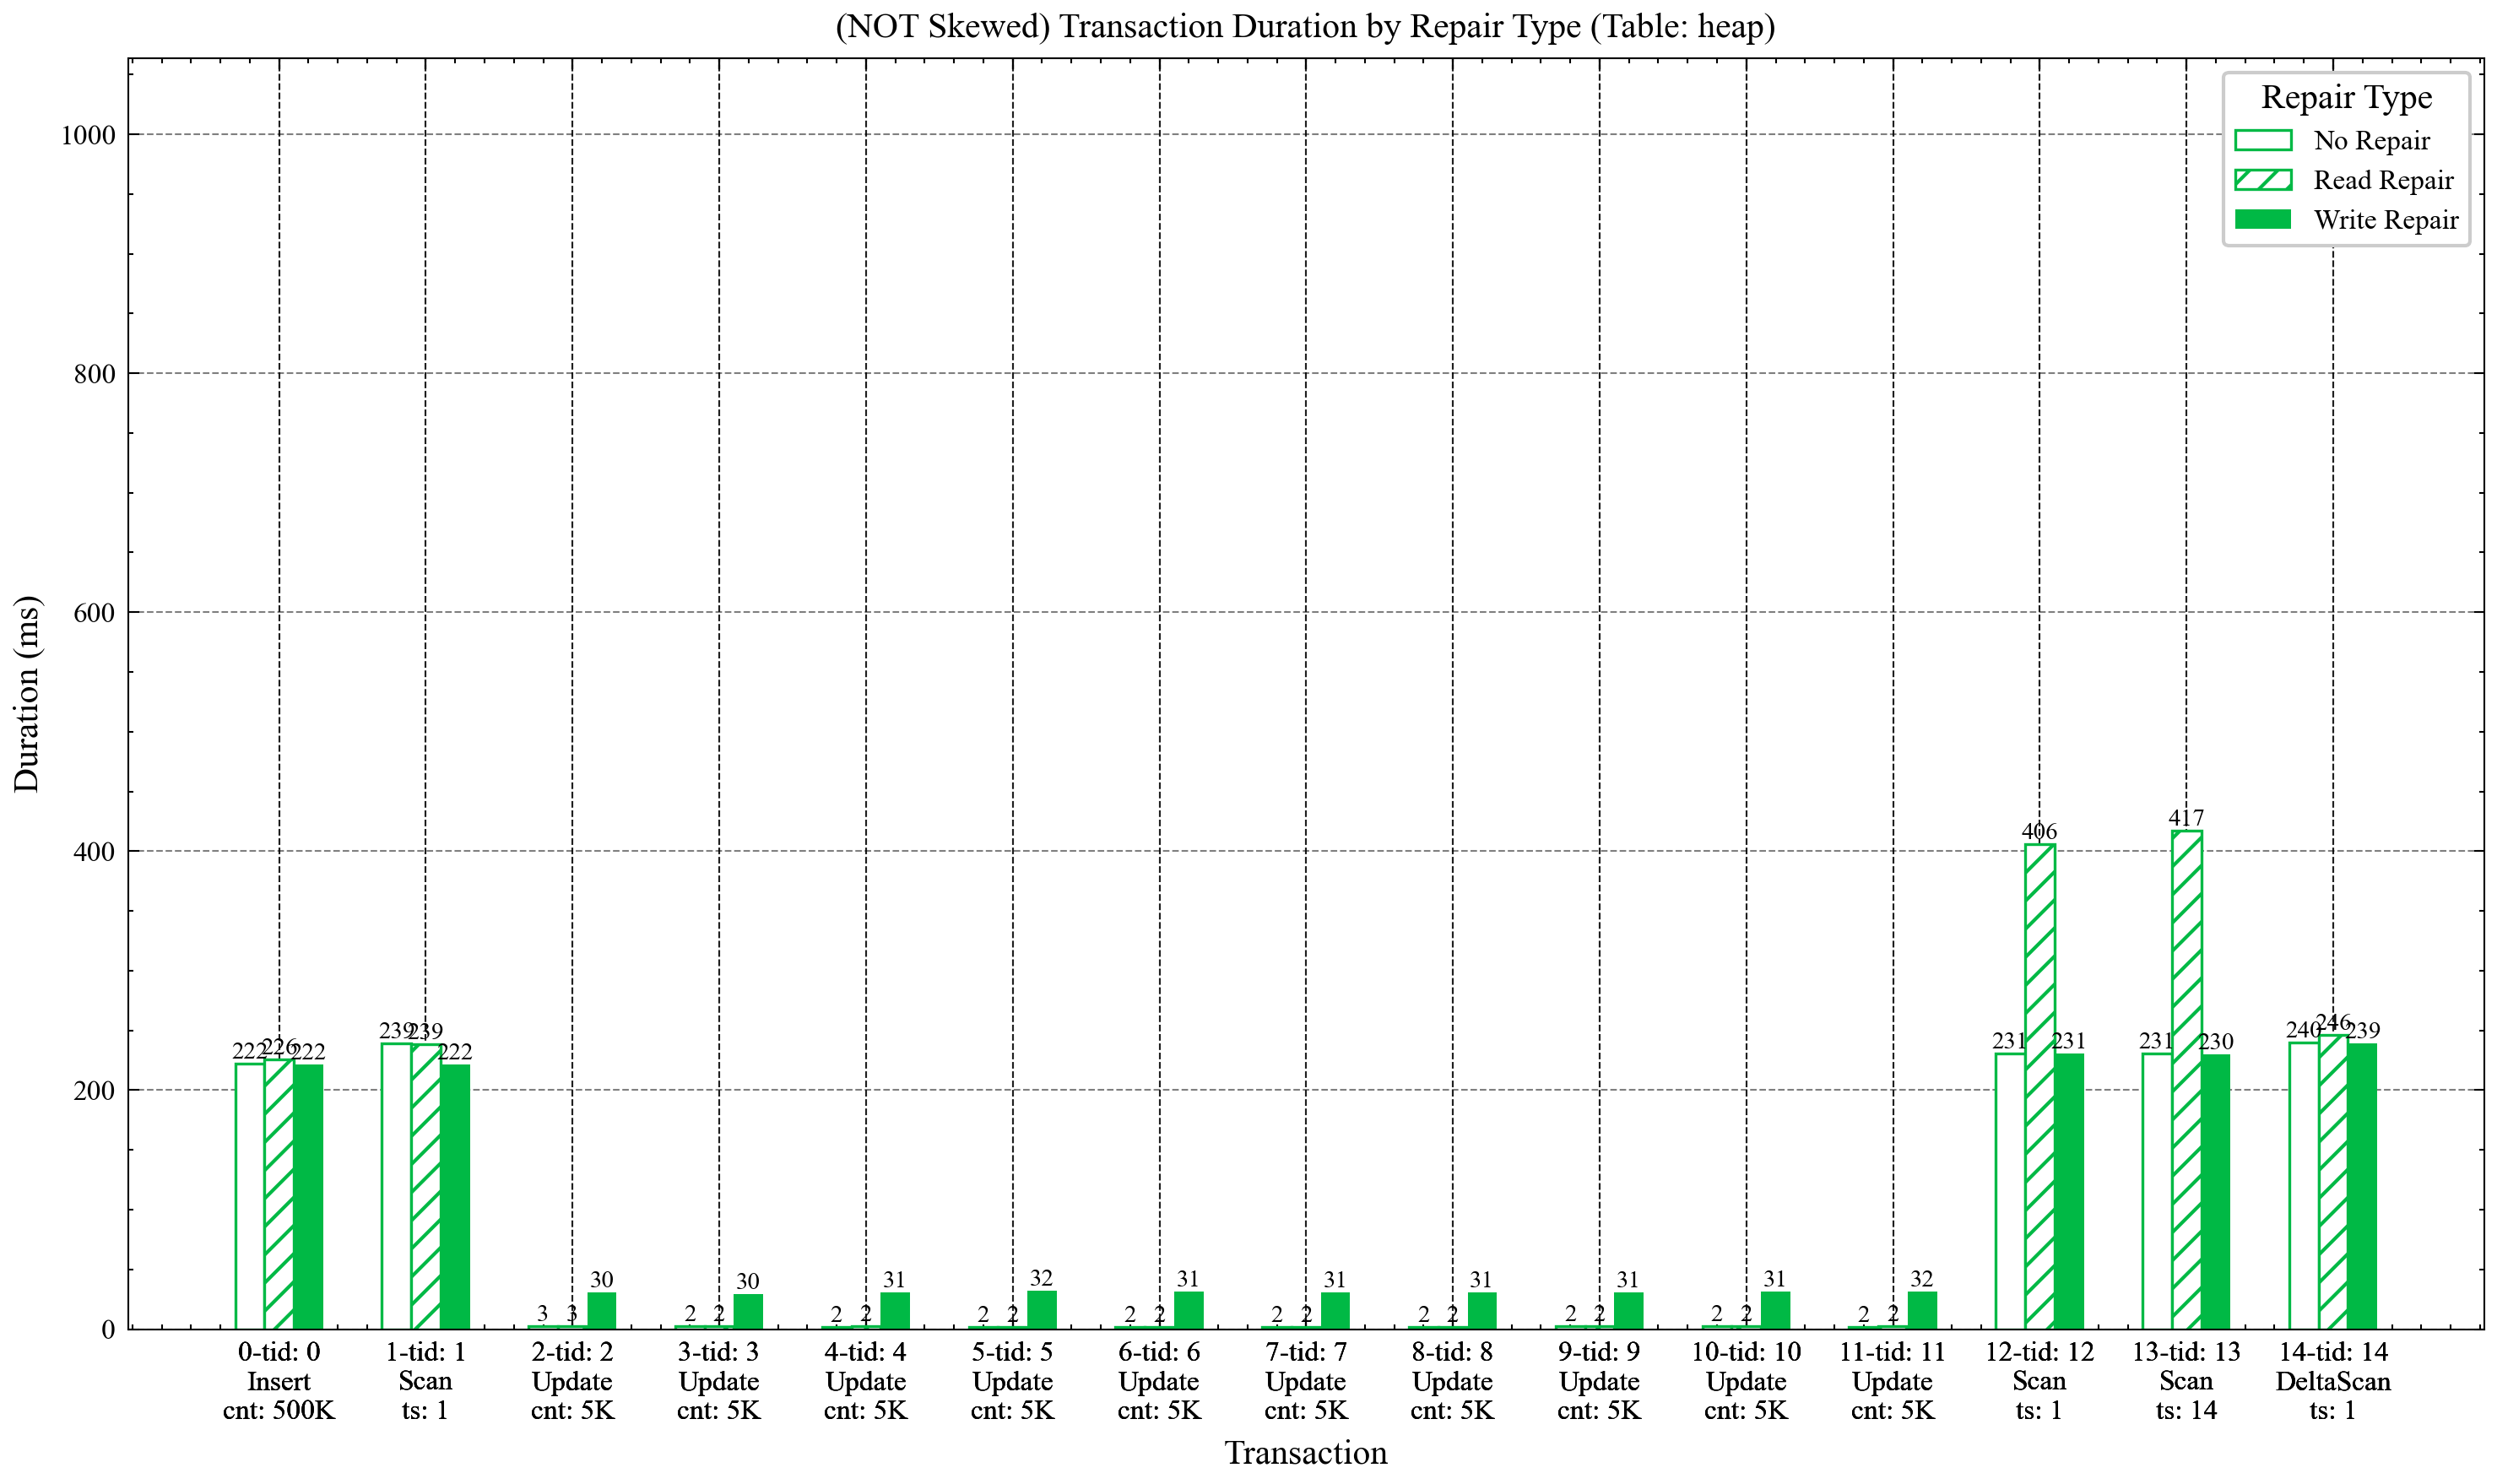

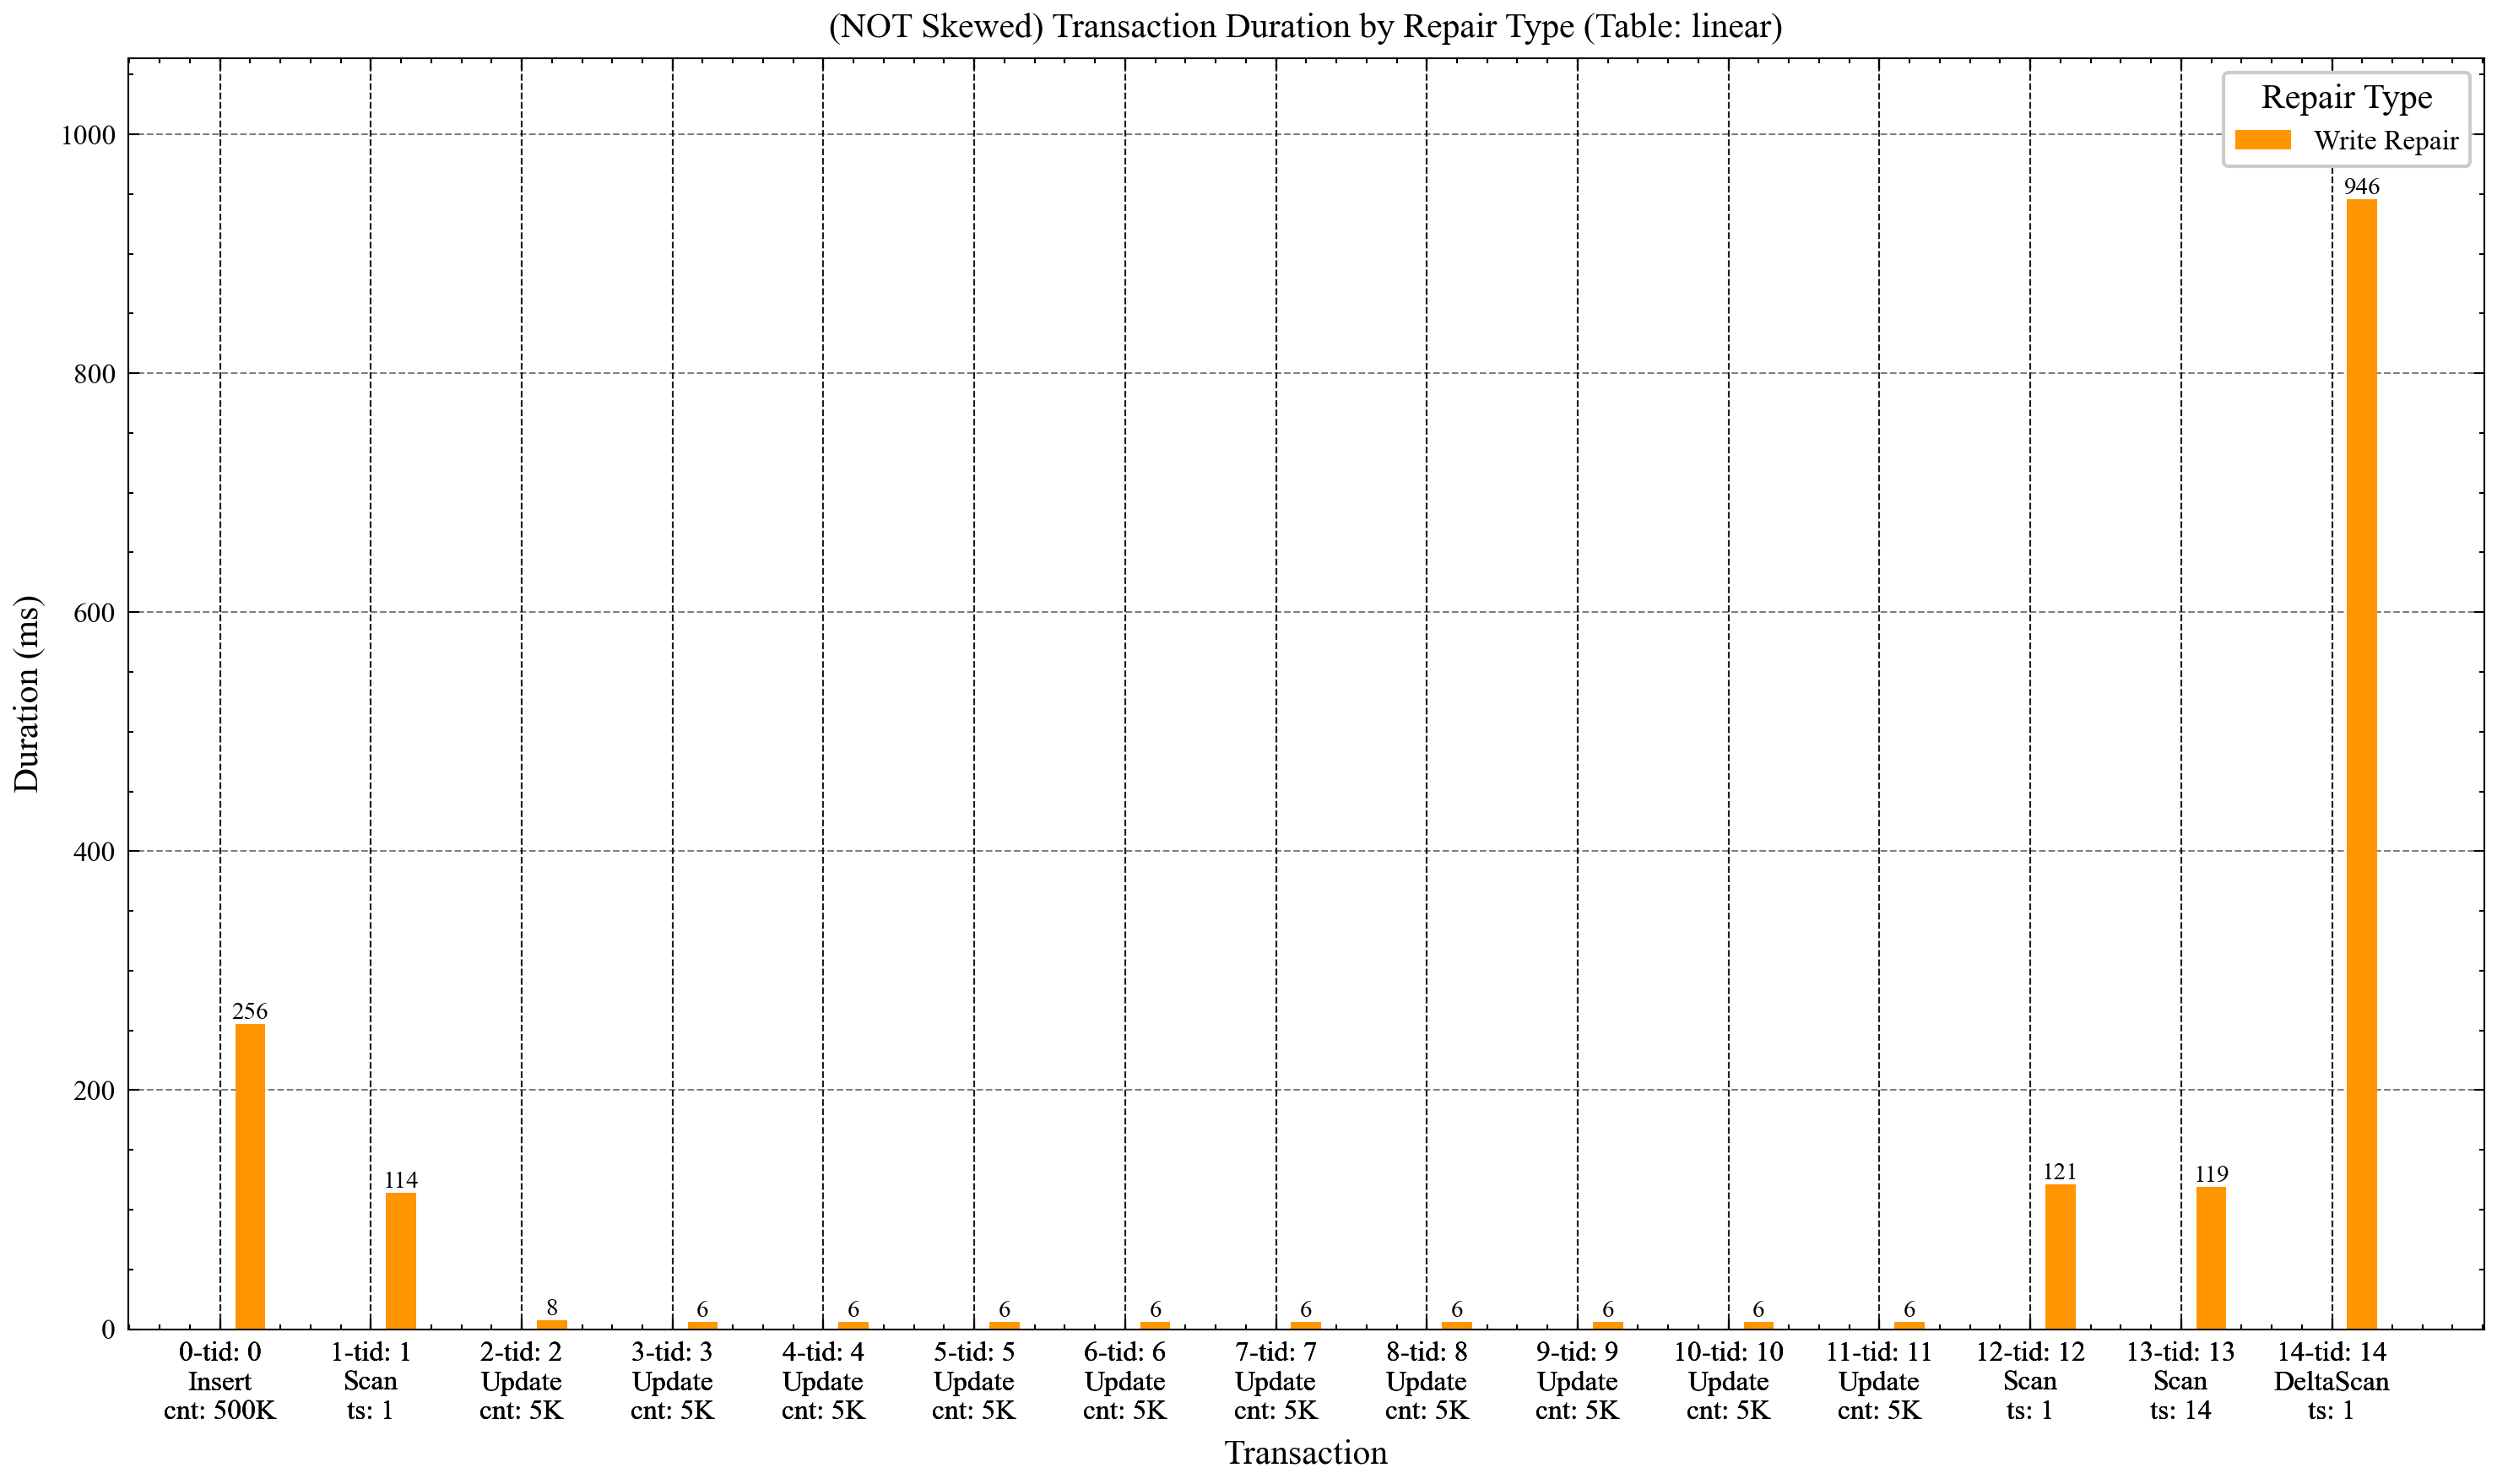

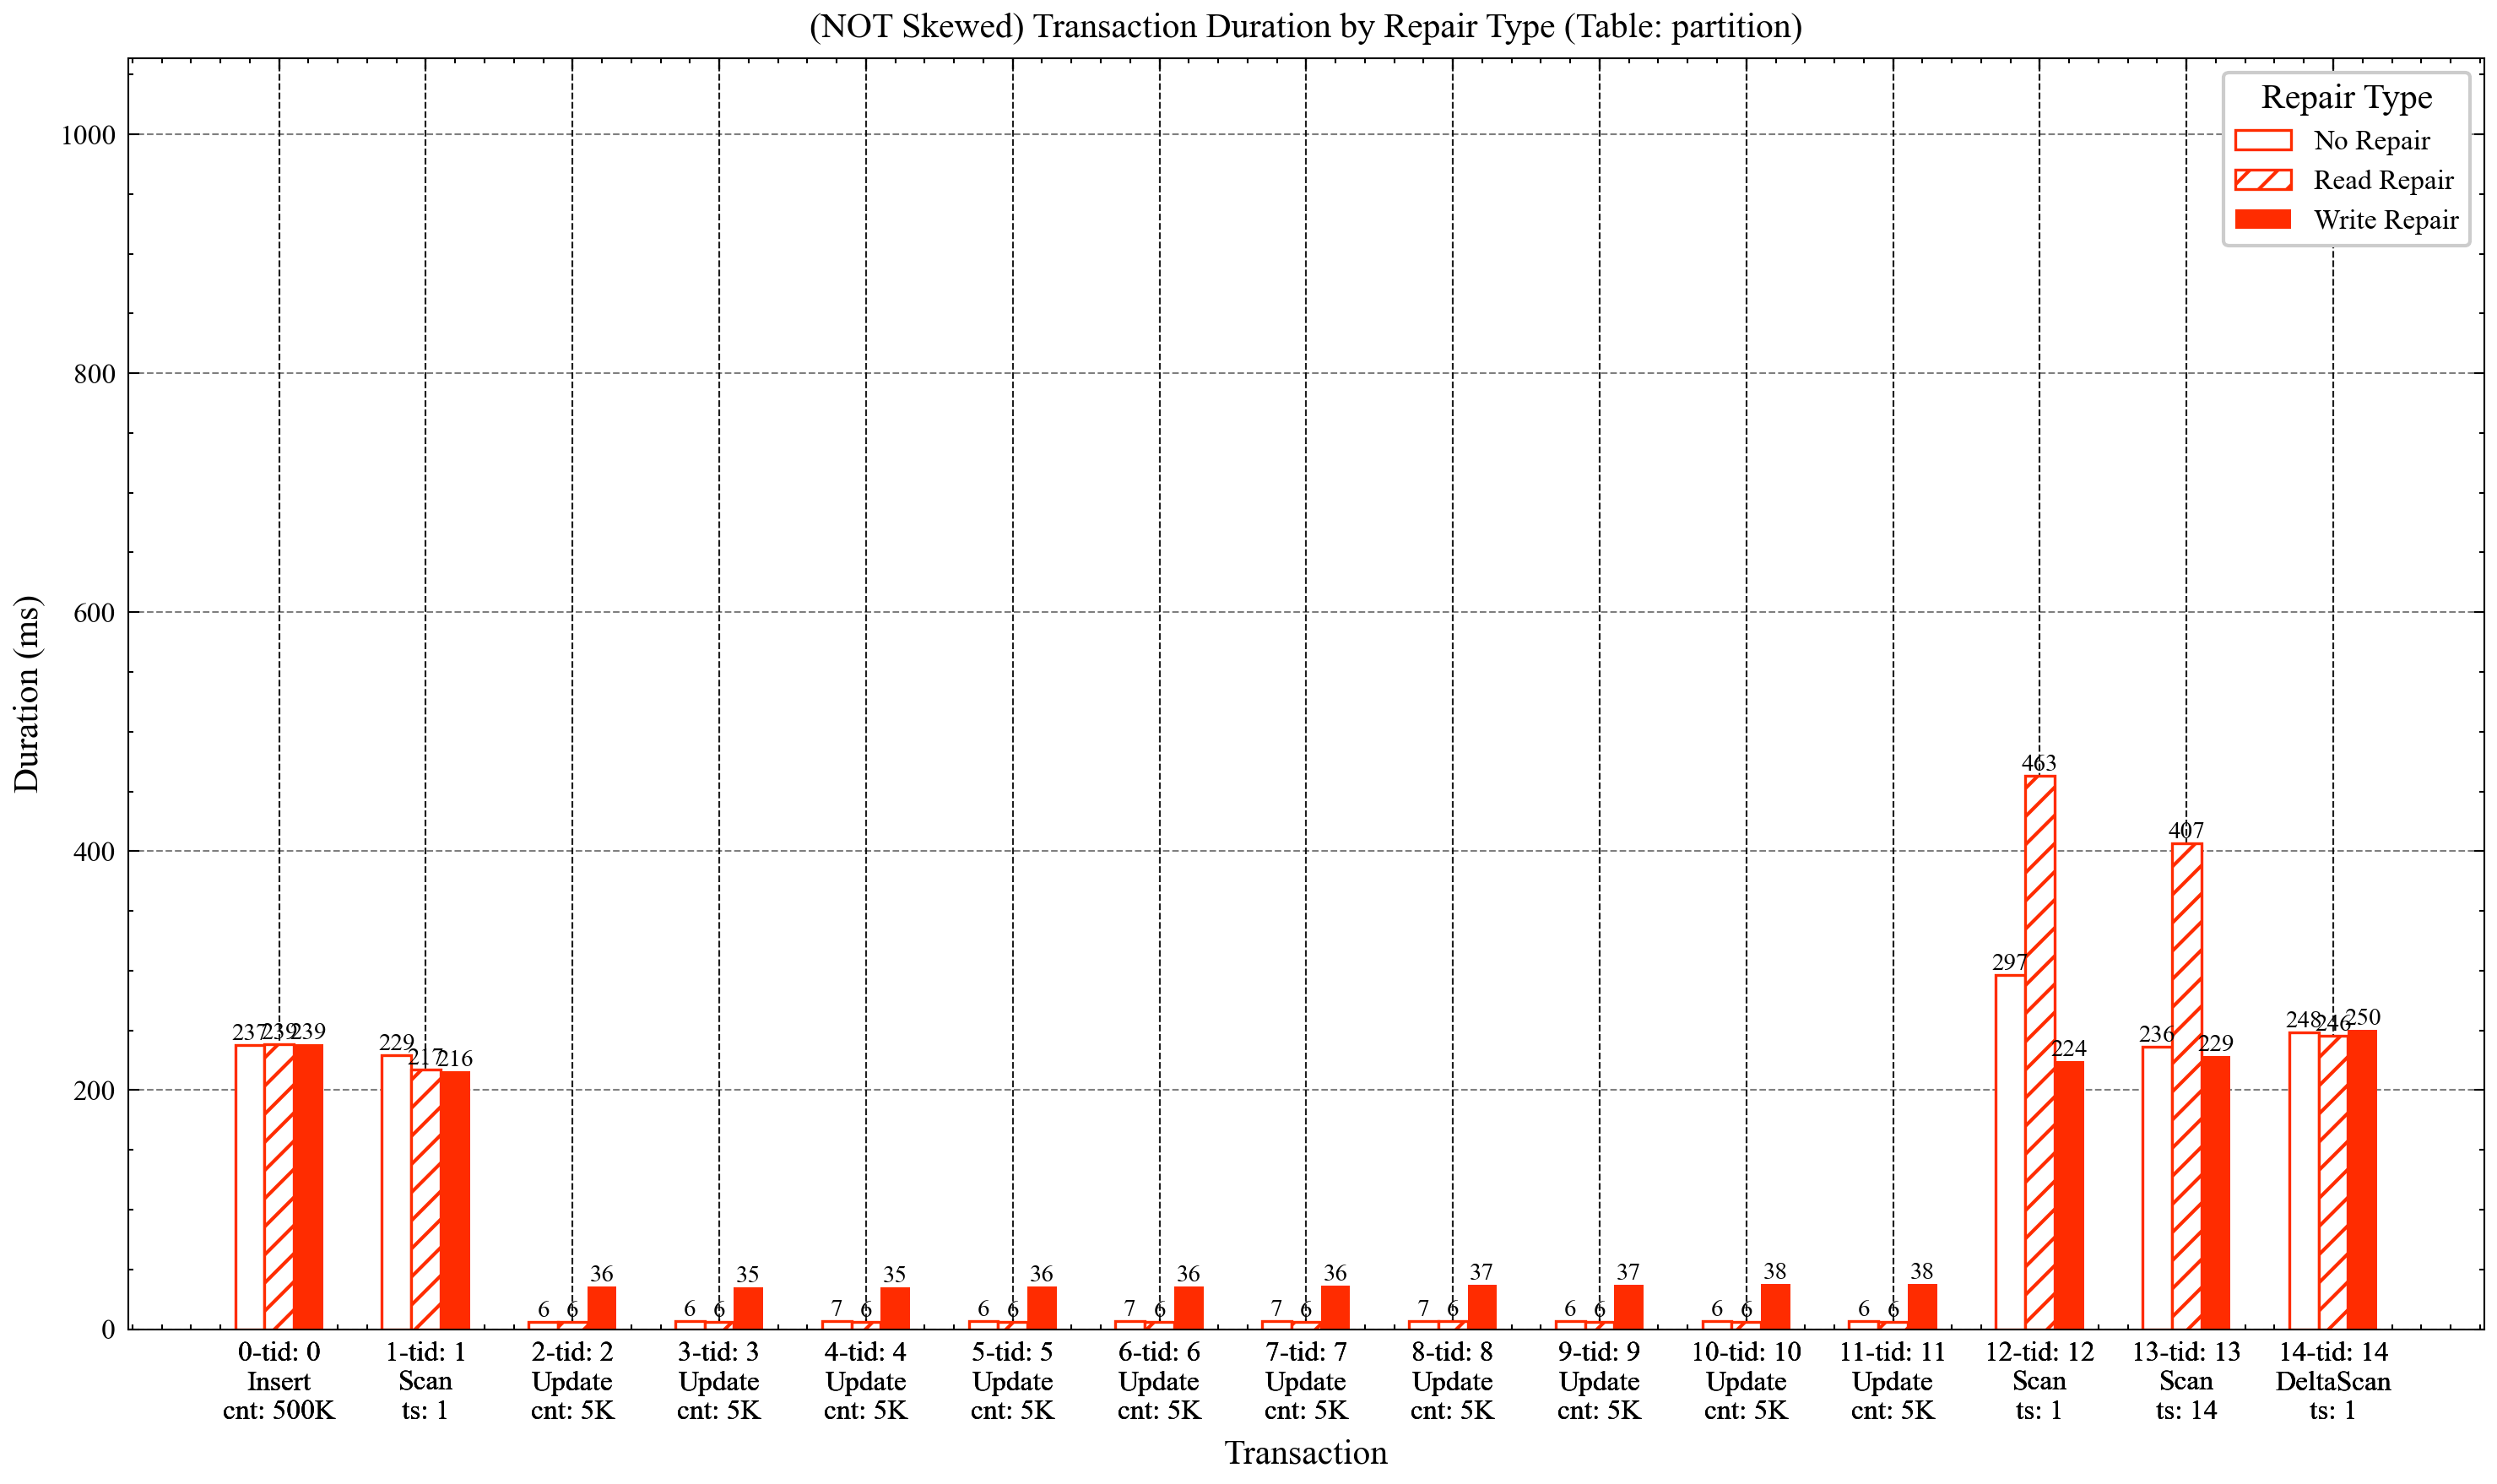

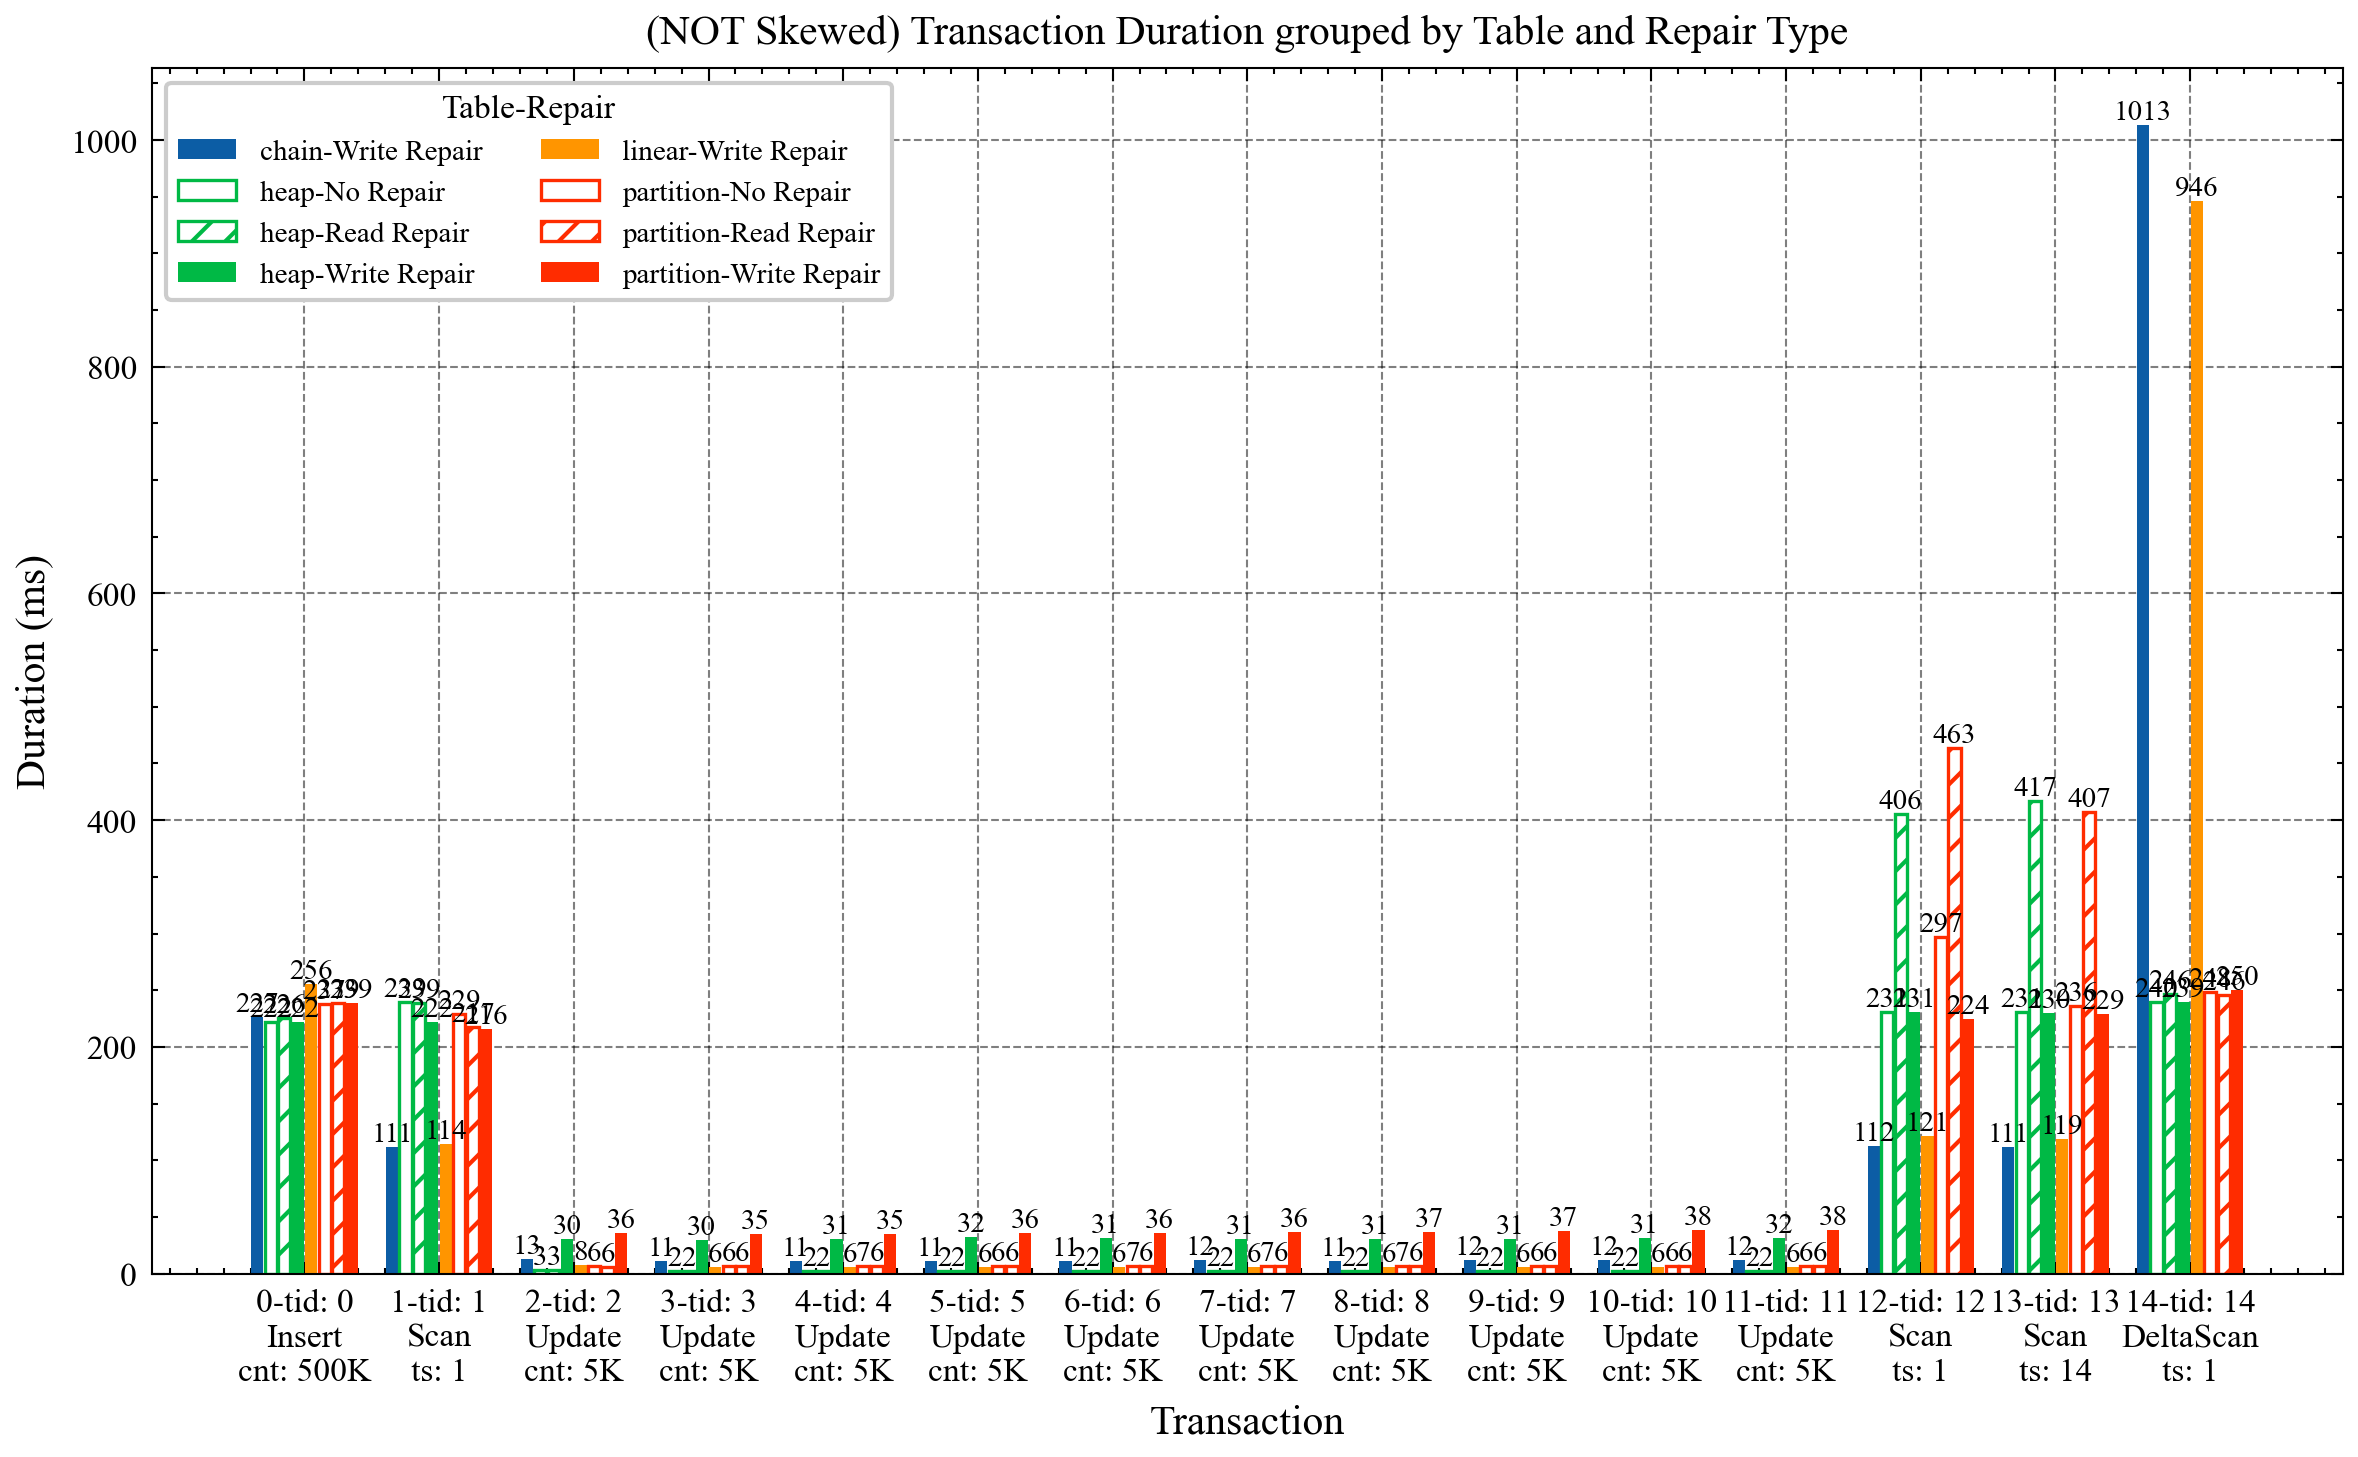

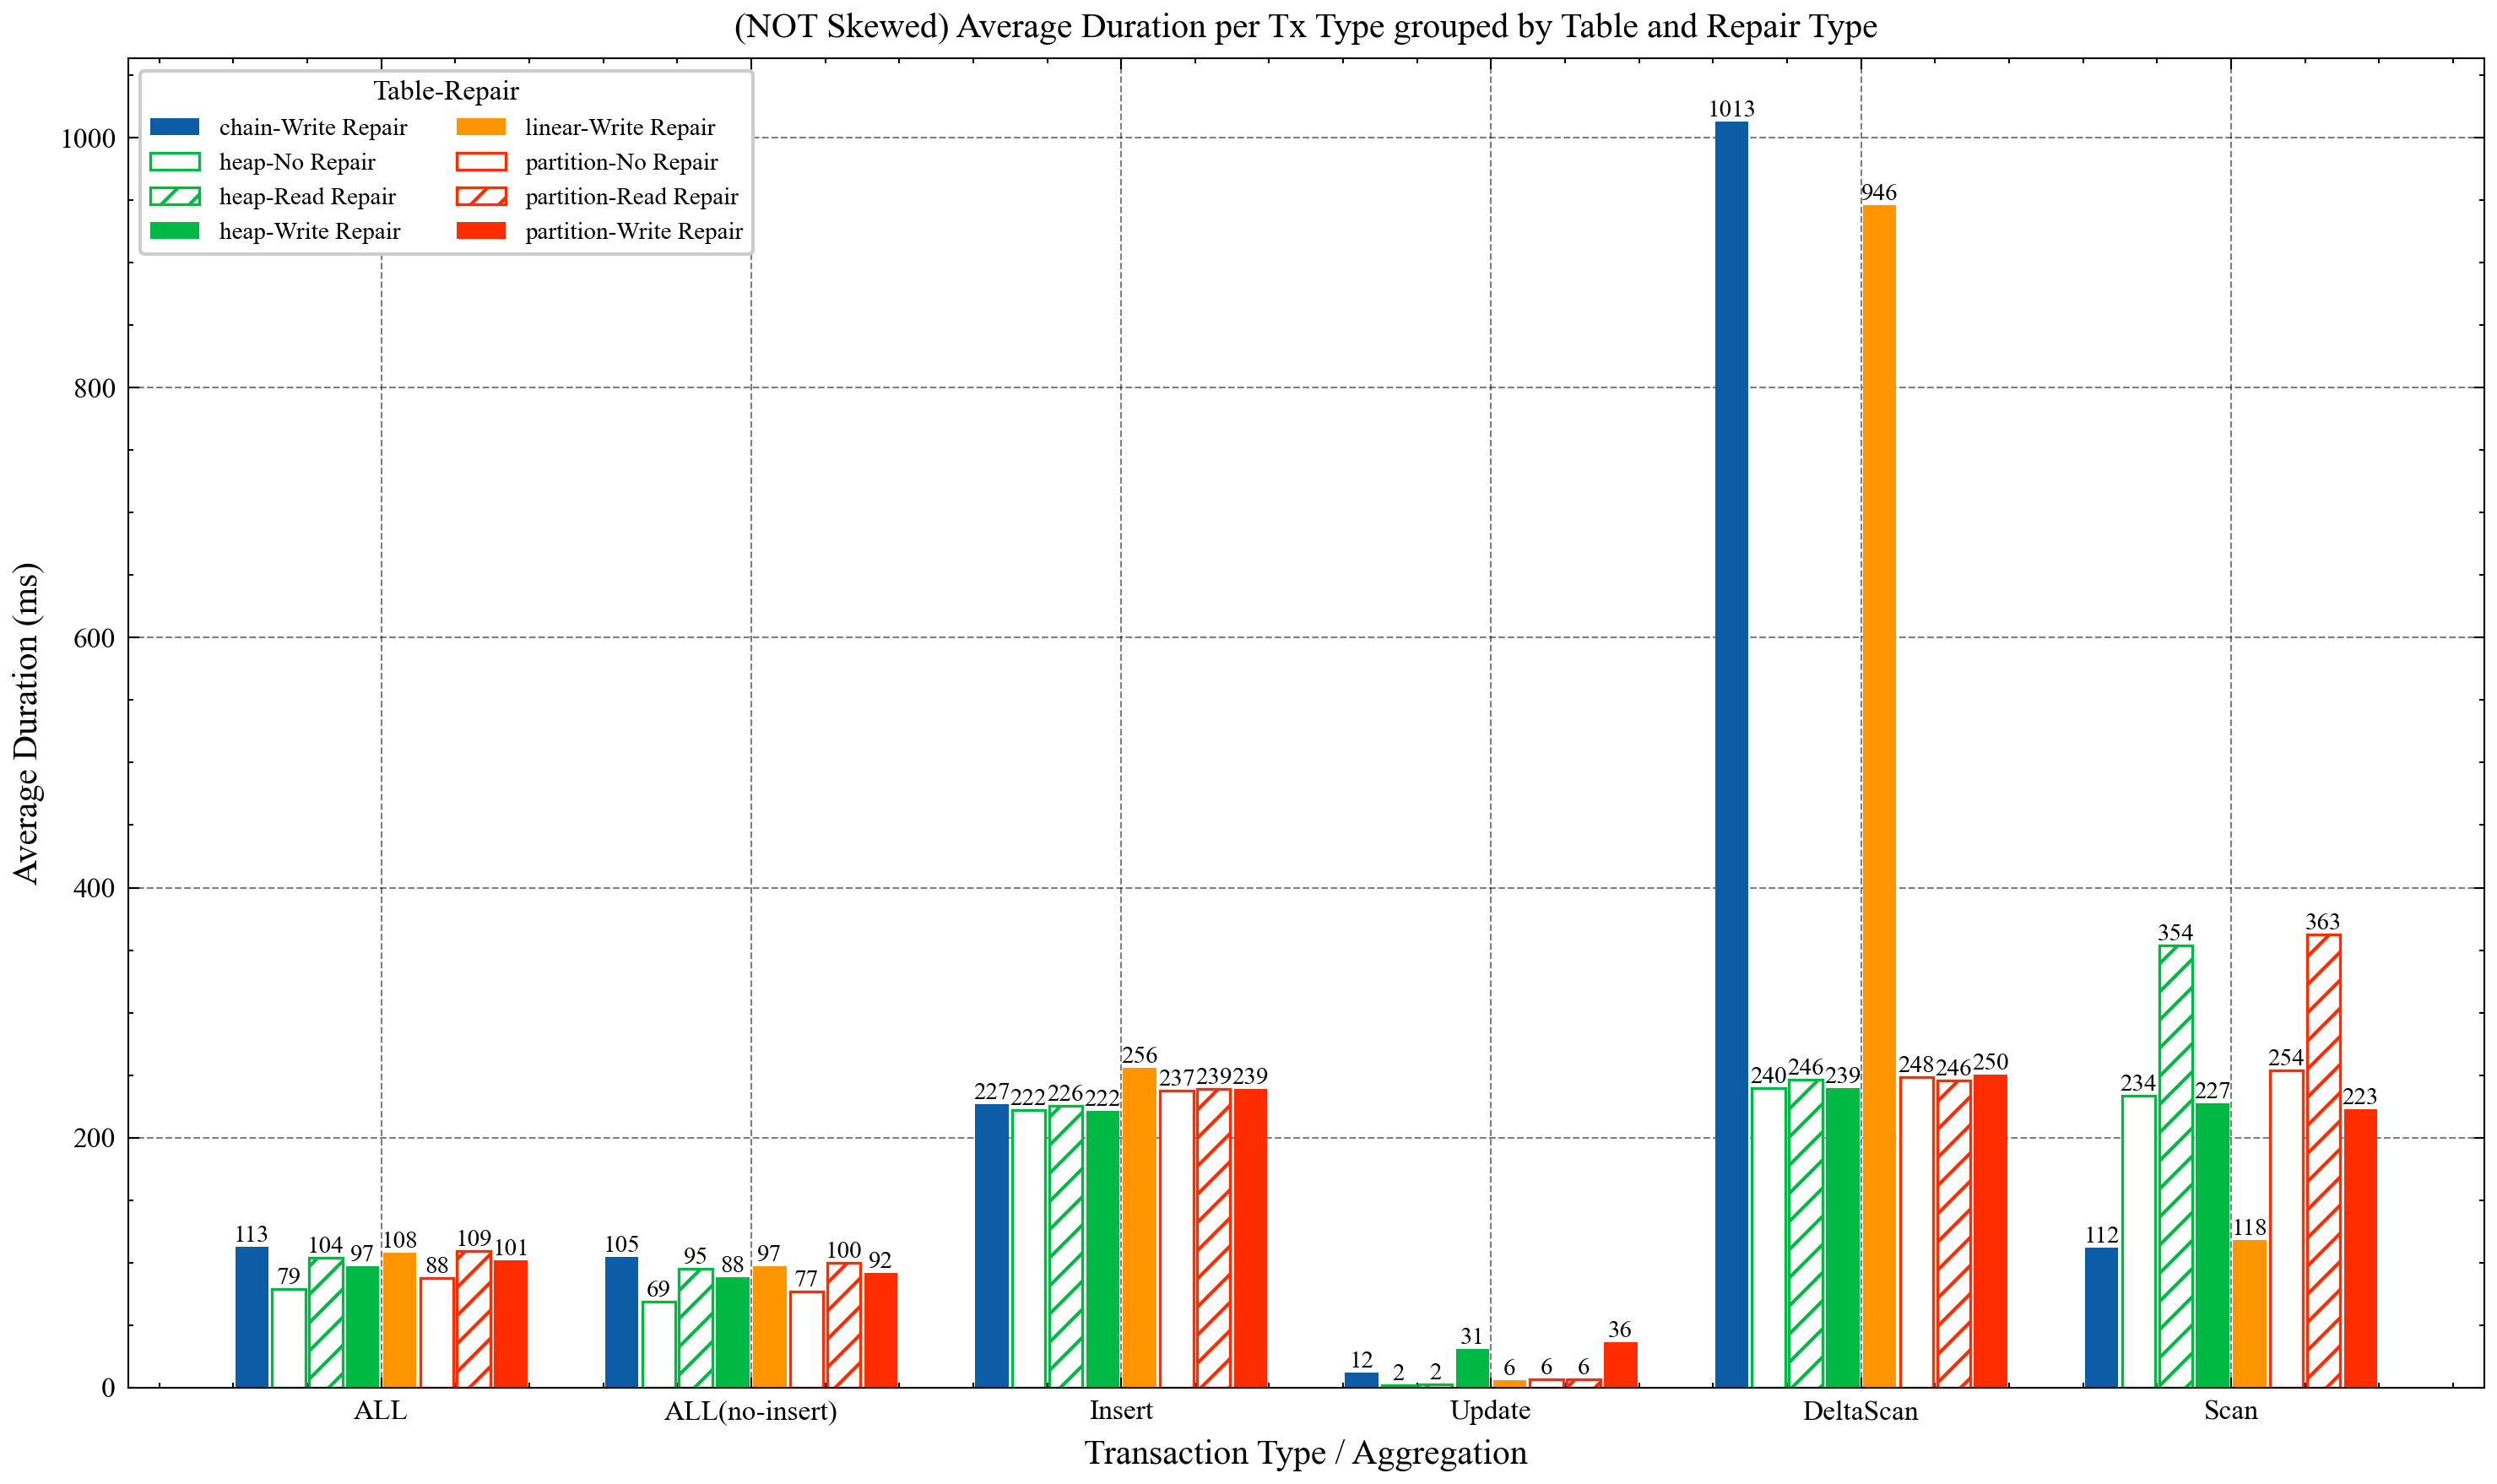

MANUAL_TXS: scan,1 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 scan,1 scan,14 delta_scan,1
Running for table_type=linear with 1 repeats...
  - Trial 1/1
Running for table_type=chain with 1 repeats...
  - Trial 1/1
Running for table_type=heap with 1 repeats...
  - Trial 1/1
Running for table_type=partition with 1 repeats...
  - Trial 1/1


,idx,tx_id,tx_type,repair_type,table_type,duration_ms,count,read_ts
0,0,0,Insert,No Repair,linear,254.135856,500000.0,NaN
1,0,0,Insert,Read Repair,linear,262.526076,500000.0,NaN
2,0,0,Insert,Write Repair,linear,256.379863,500000.0,NaN
3,1,1,Scan,No Repair,linear,114.880285,NaN,1.0
4,1,1,Scan,Read Repair,linear,117.155727,NaN,1.0
...,...,...,...,...,...,...,...,...
175,13,13,Scan,Read Repair,partition,408.290932,NaN,14.0
176,13,13,Scan,Write Repair,partition,212.993166,NaN,14.0
177,14,14,DeltaScan,No Repair,partition,223.775713,NaN,1.0
178,14,14,DeltaScan,Read Repair,partition,238.551108,NaN,1.0


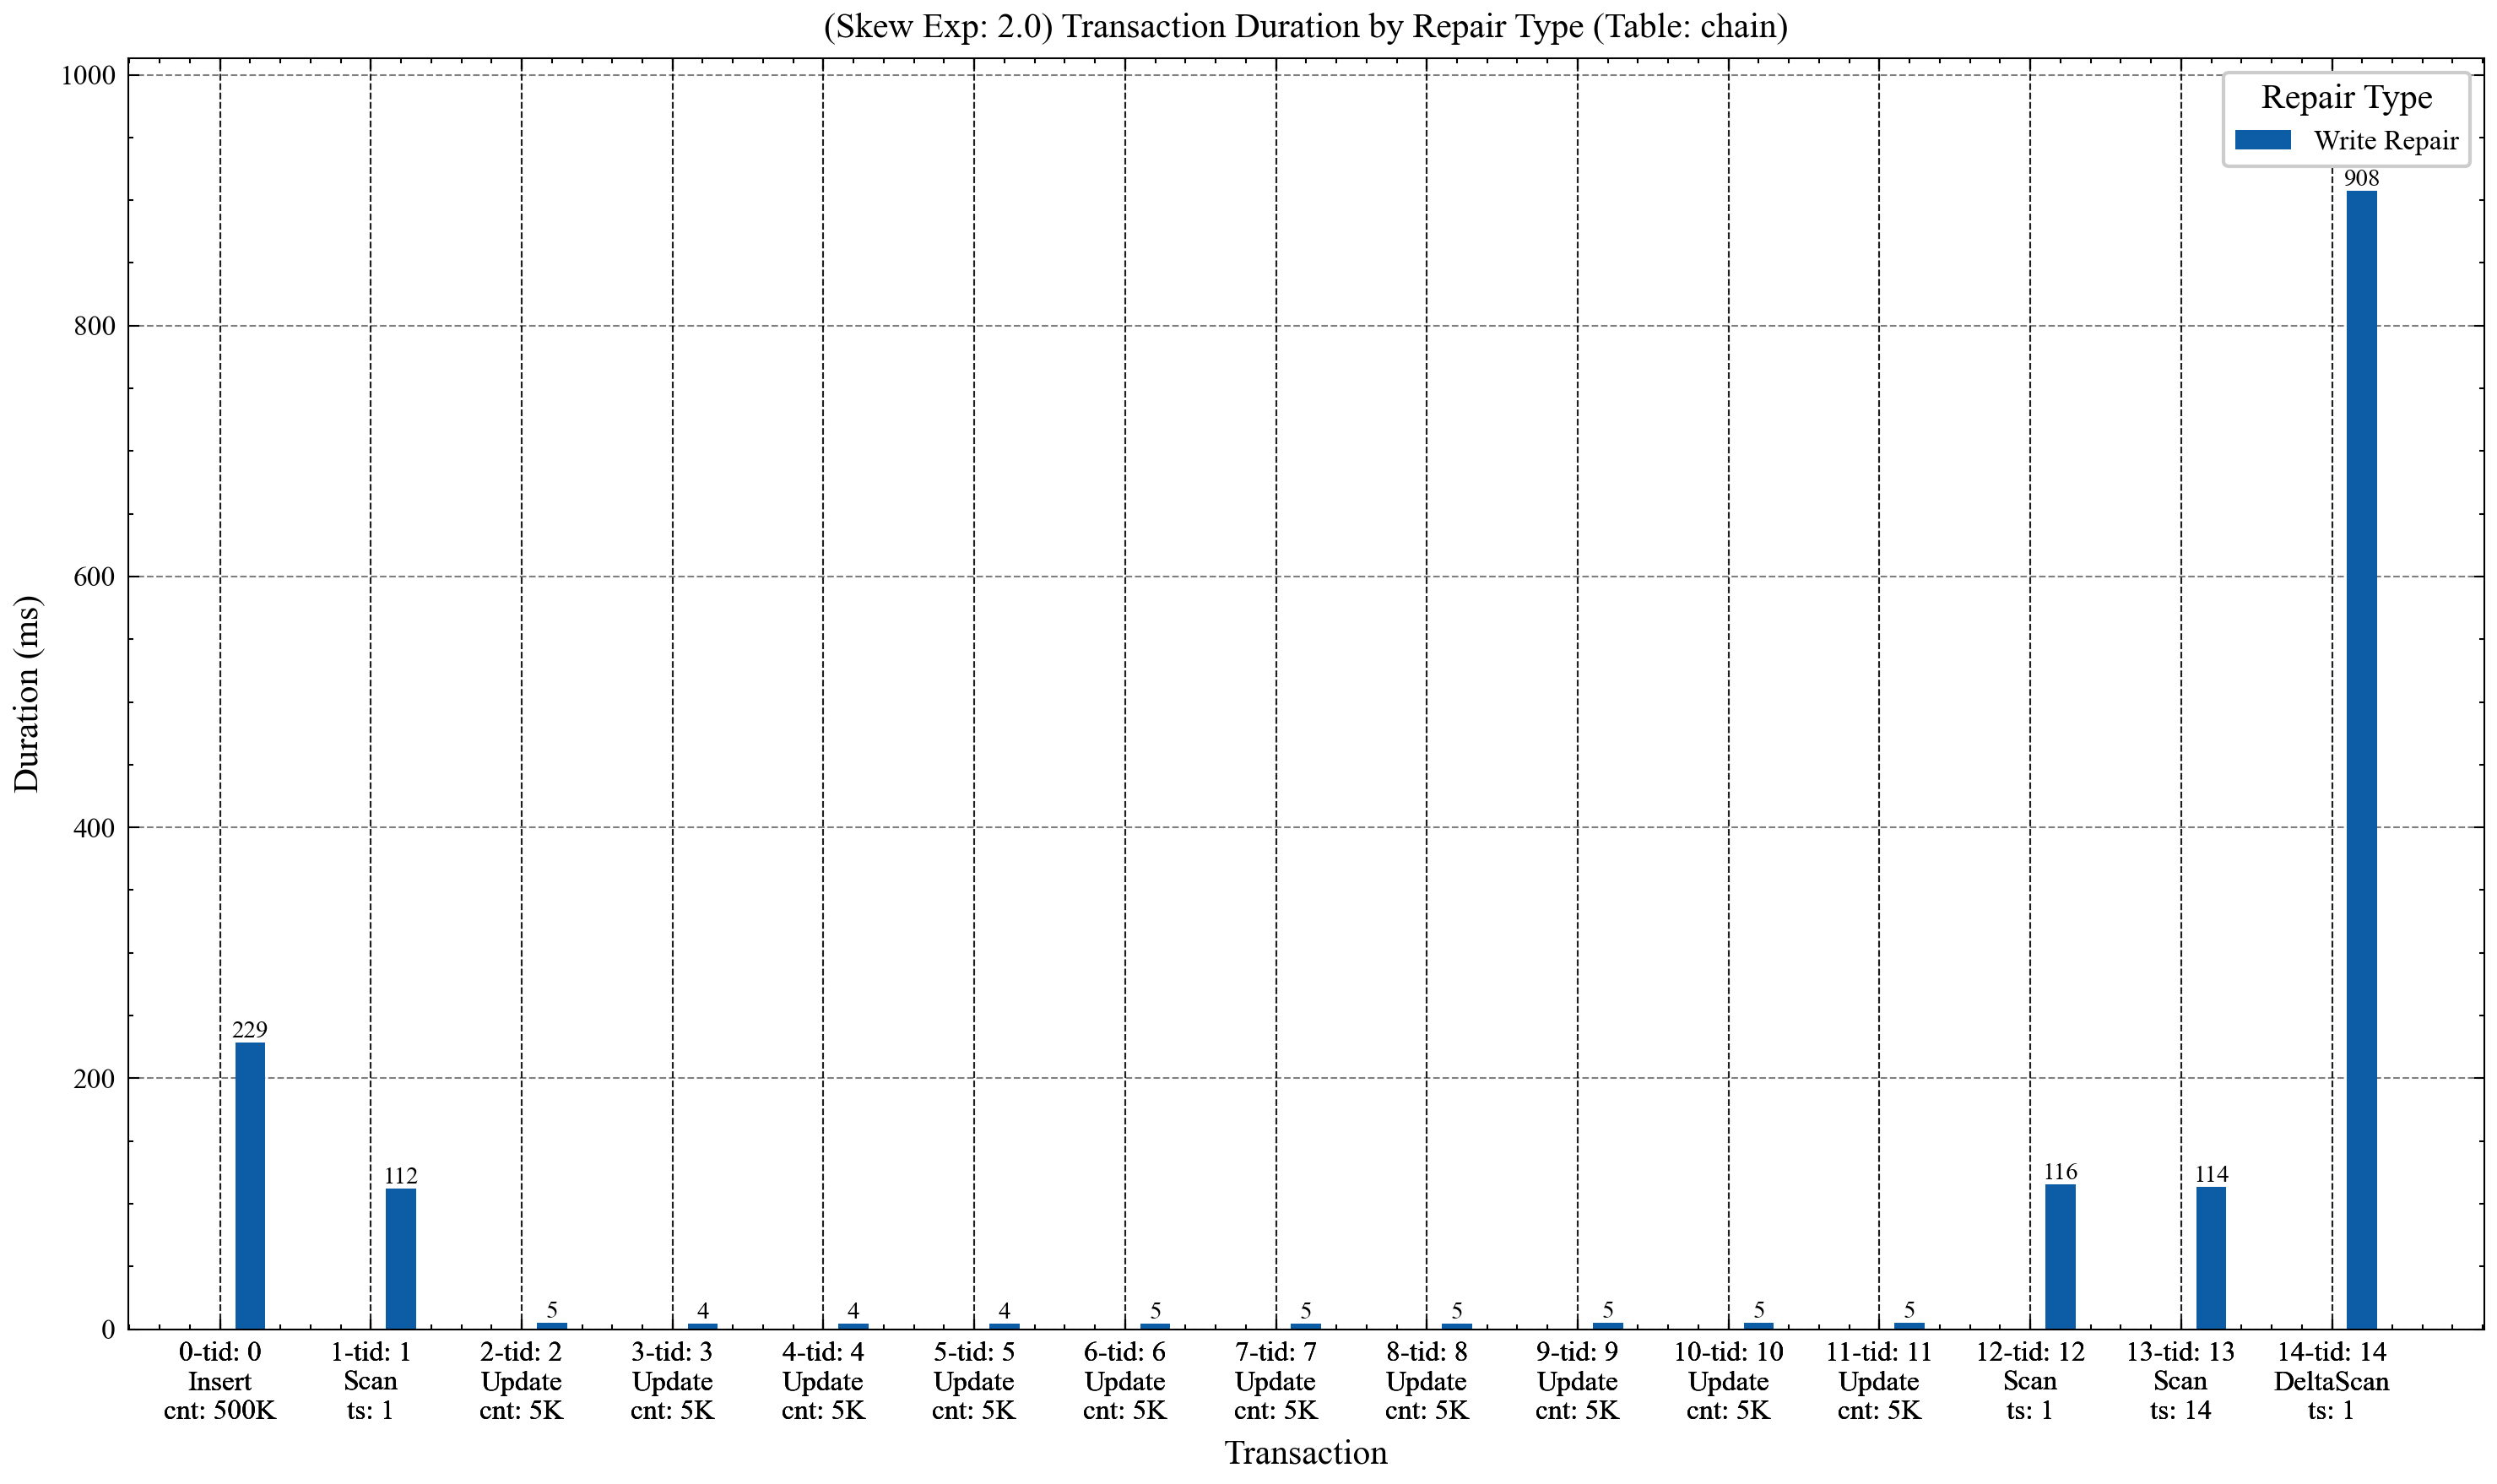

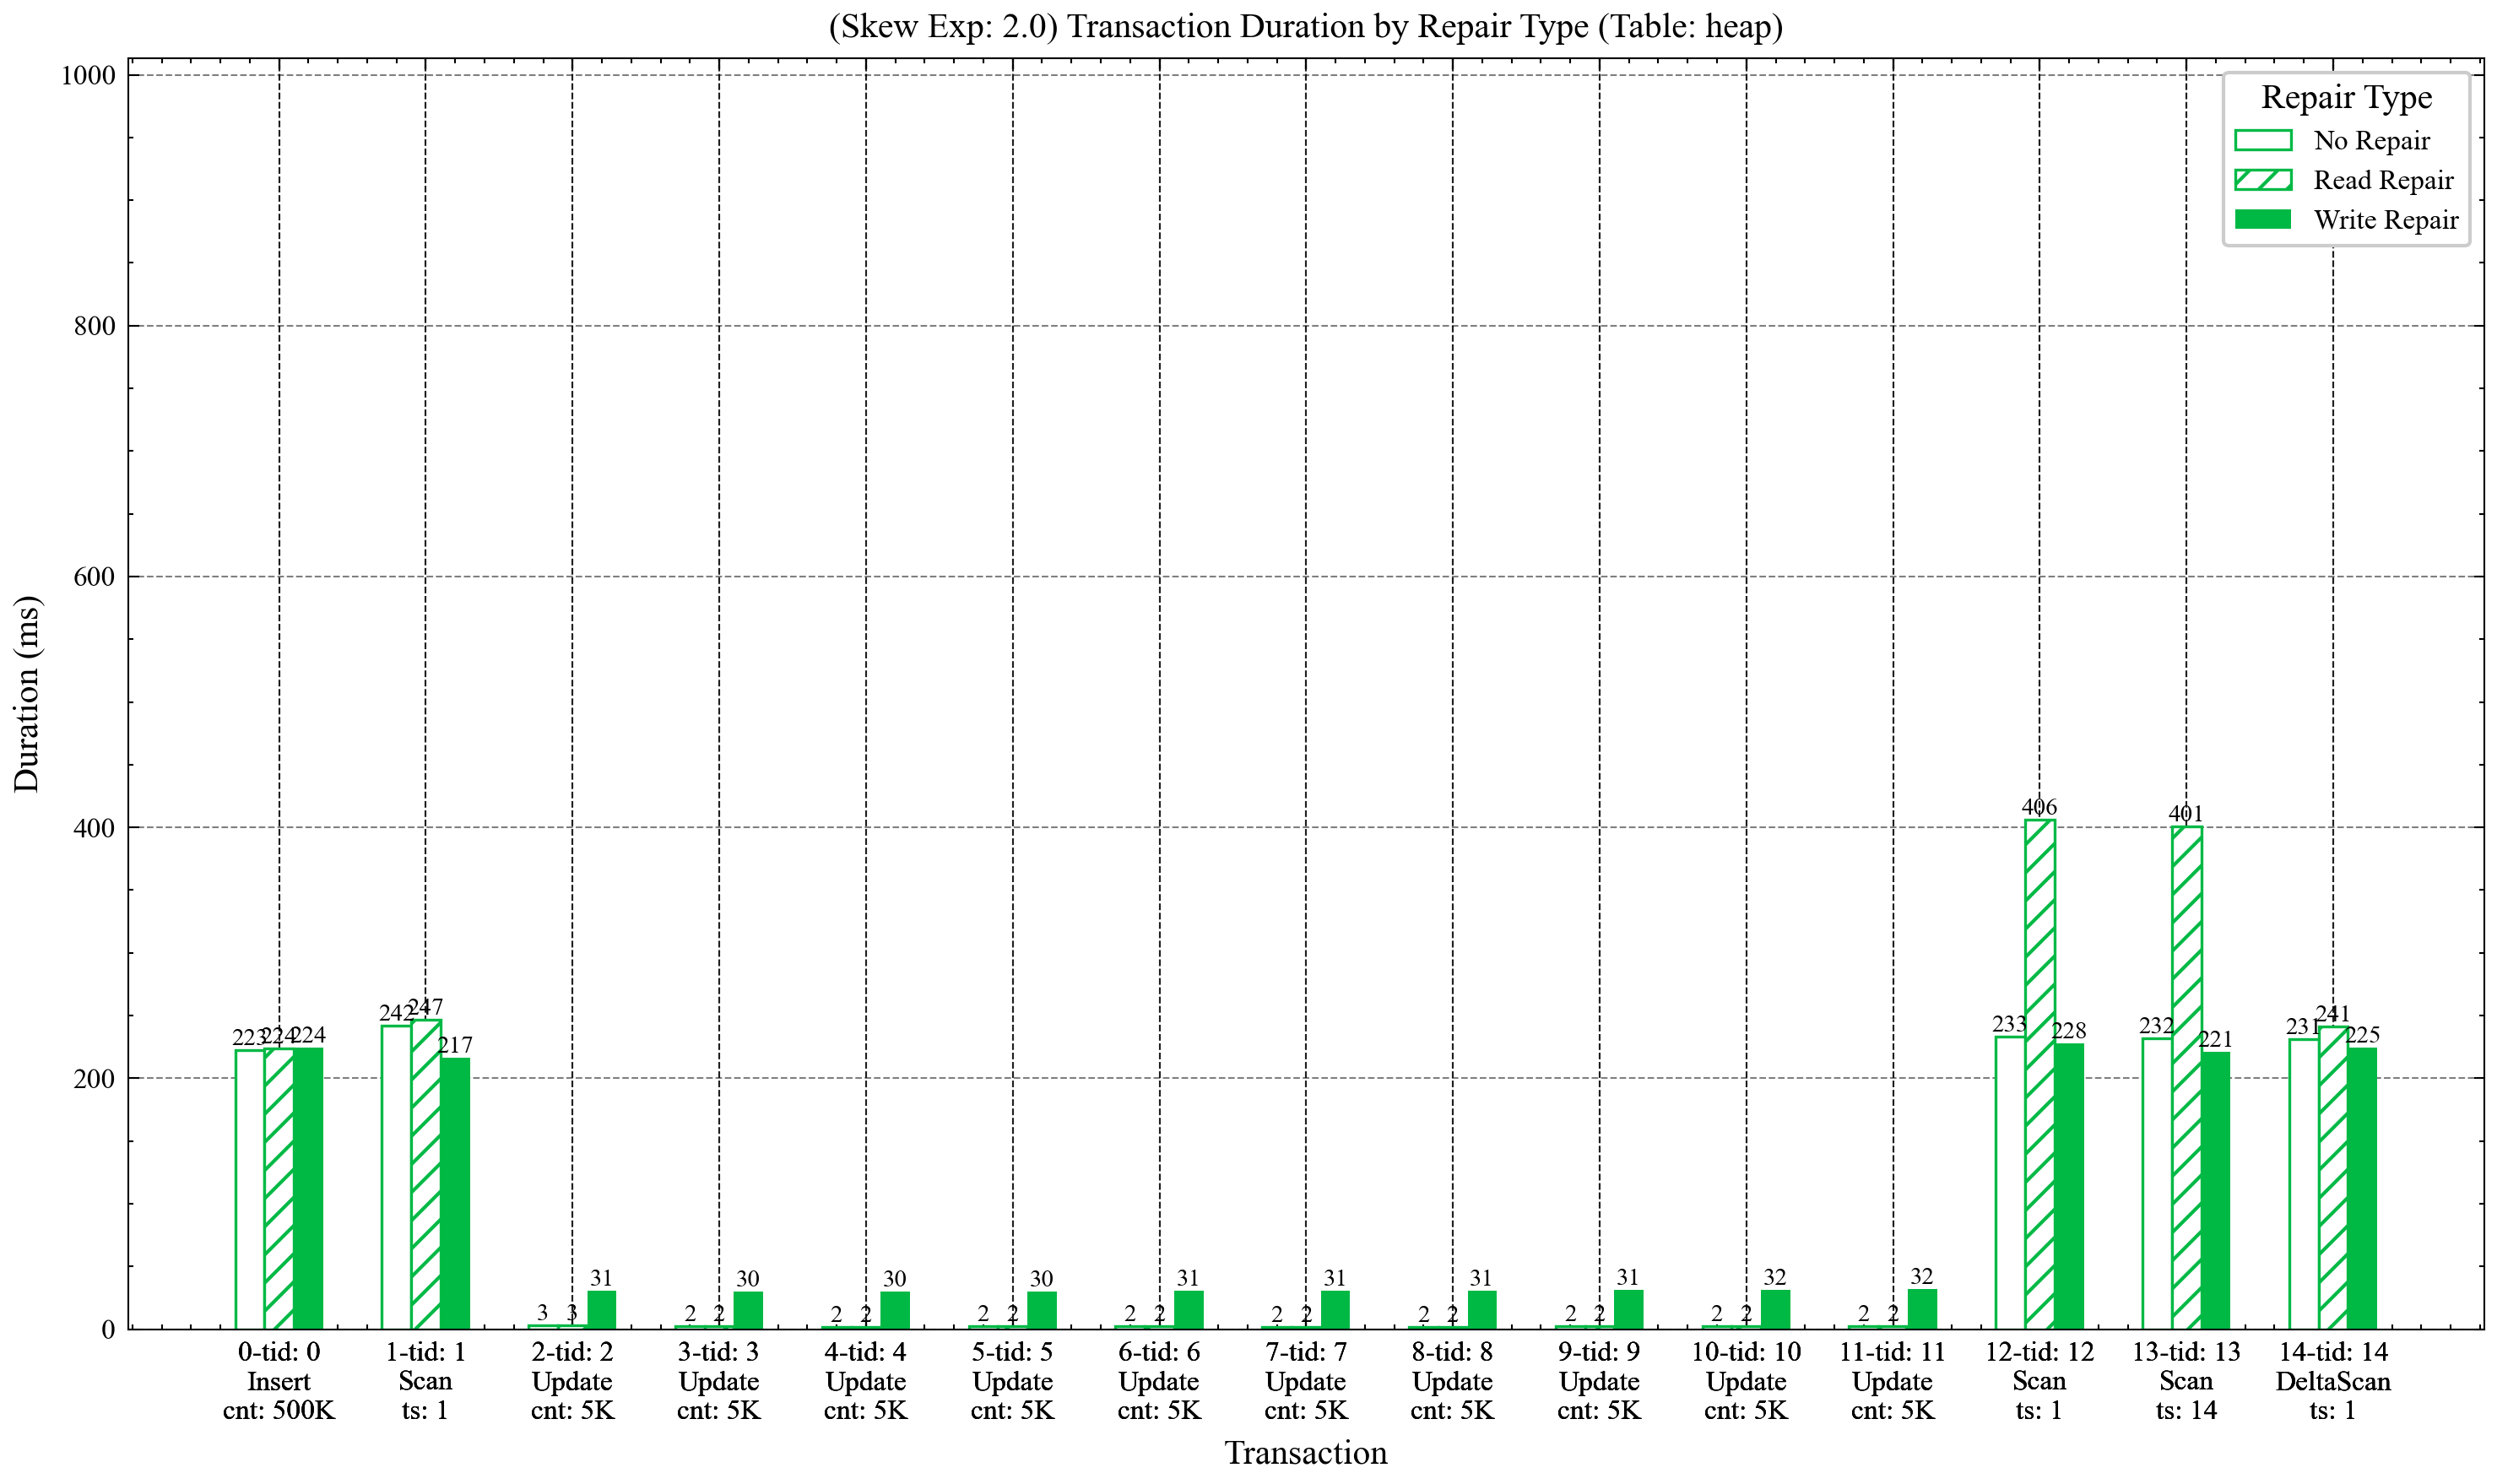

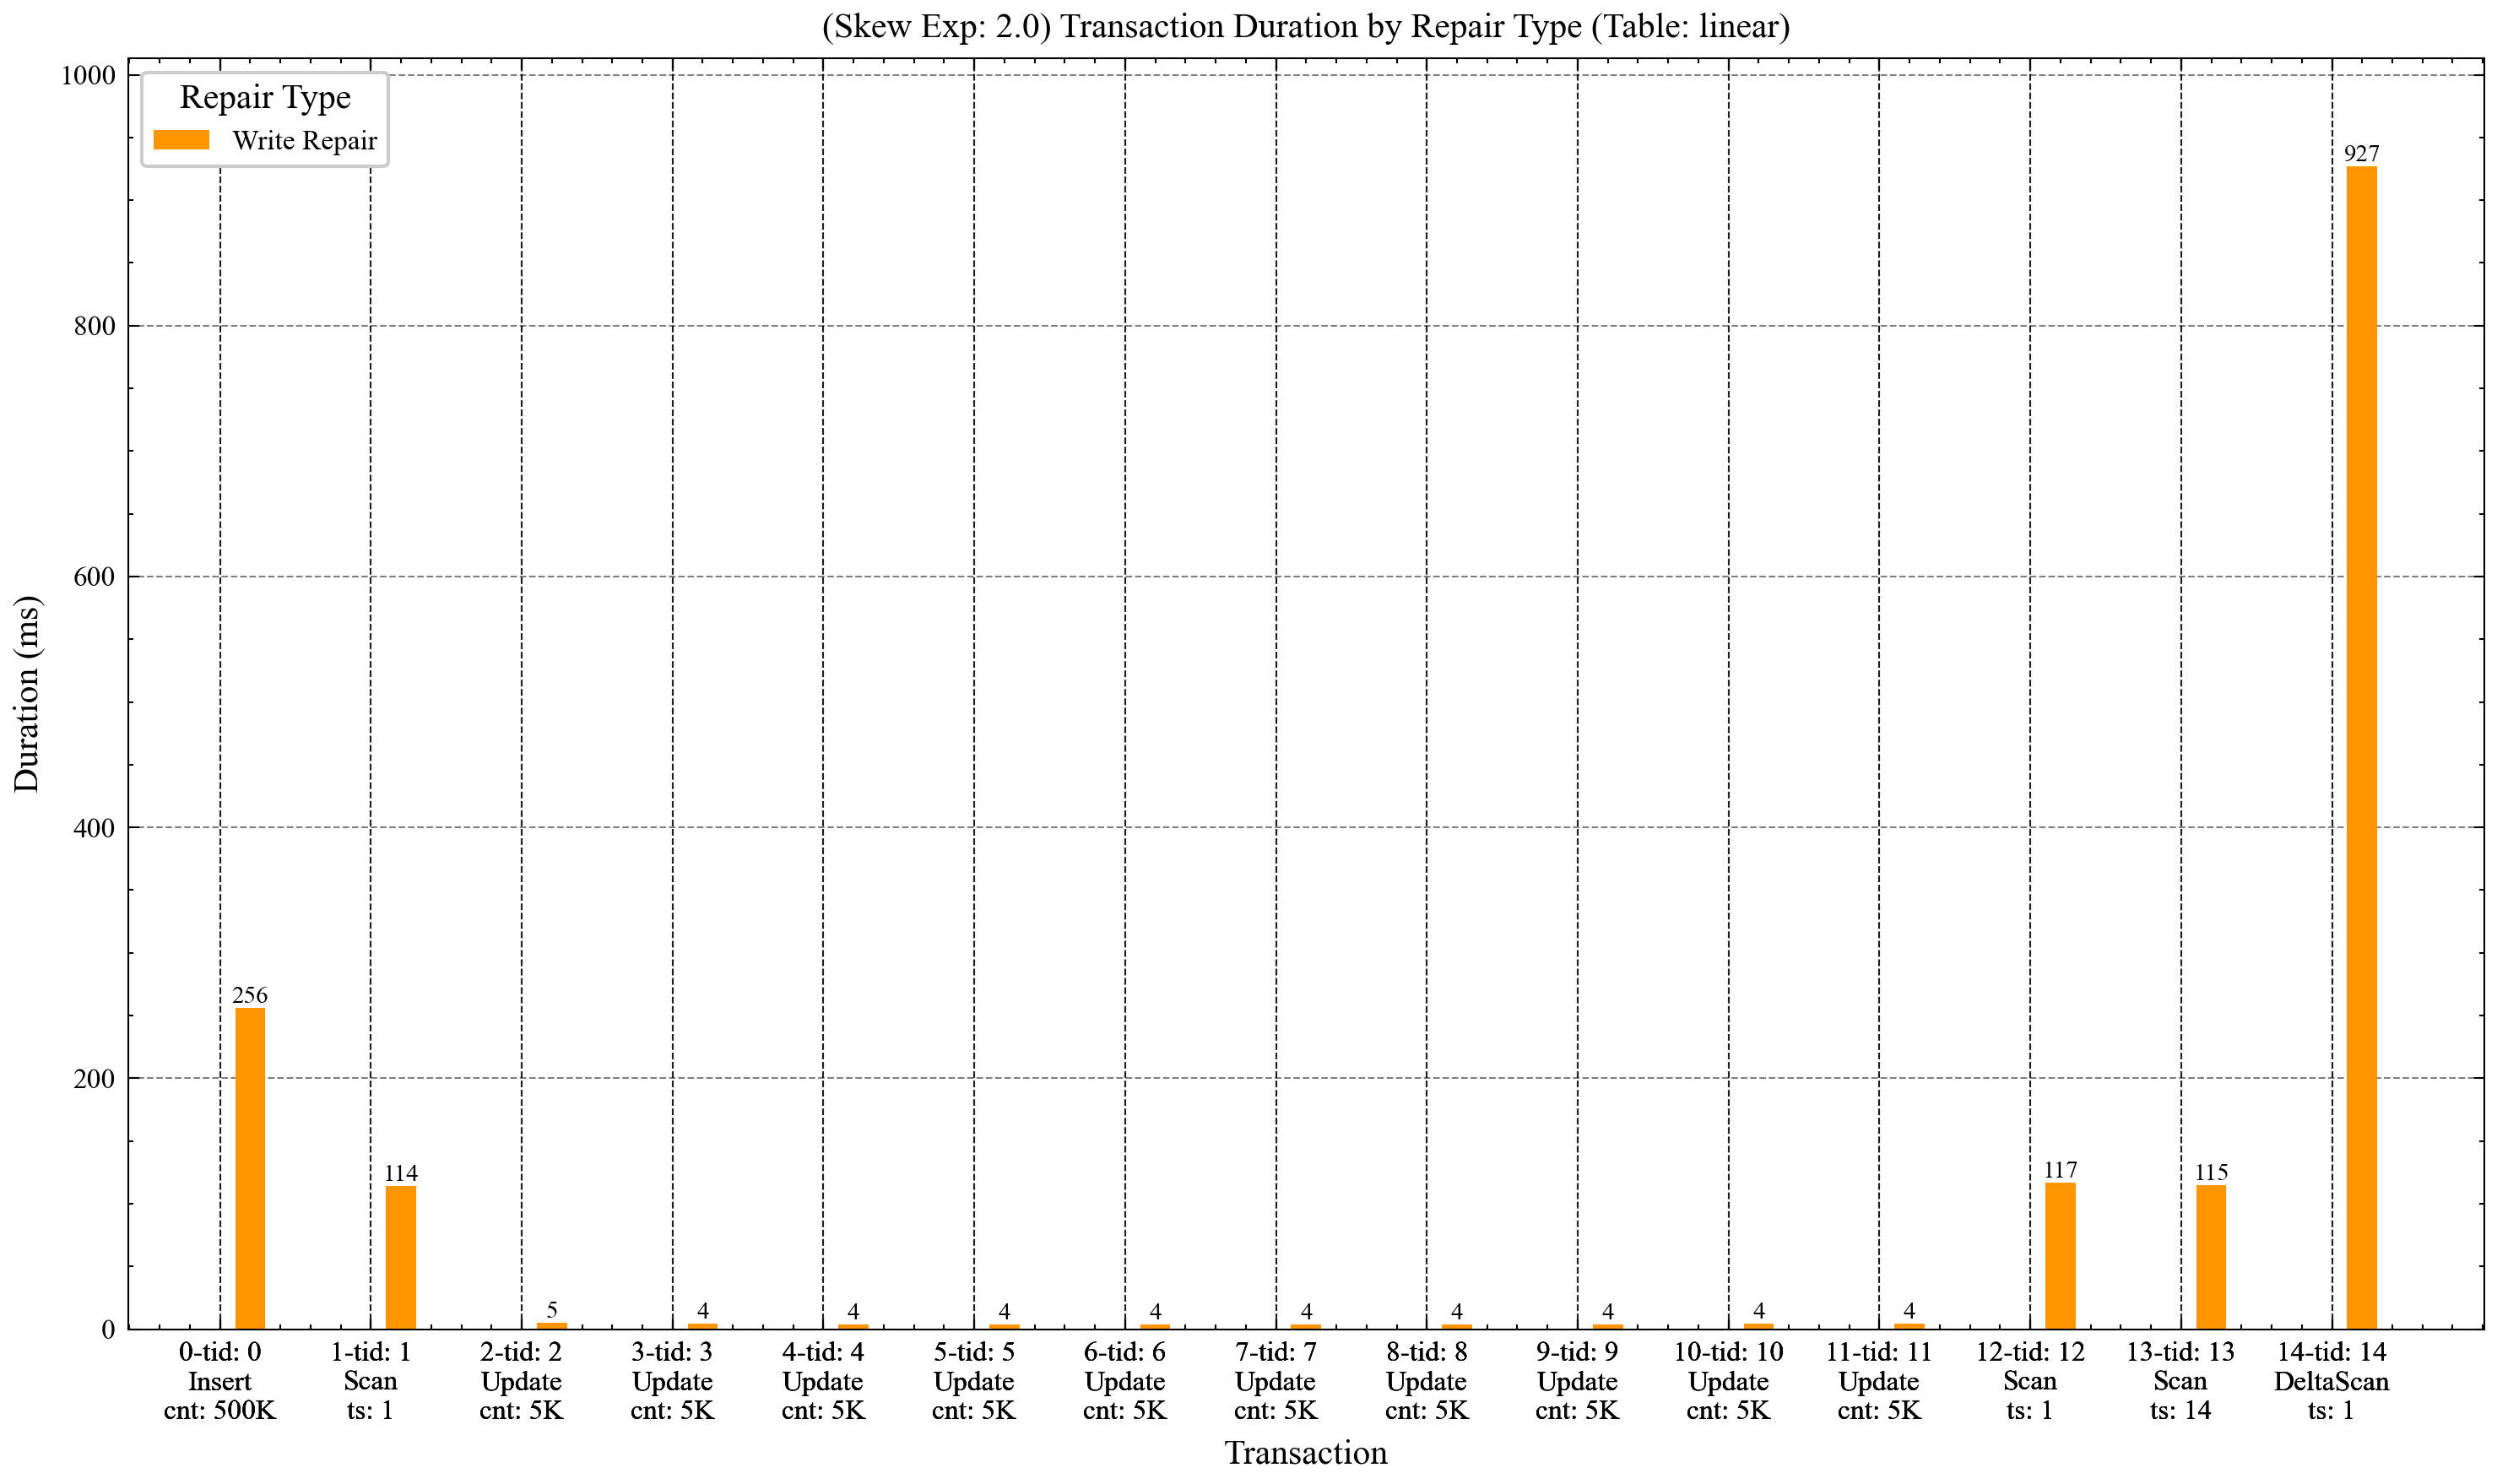

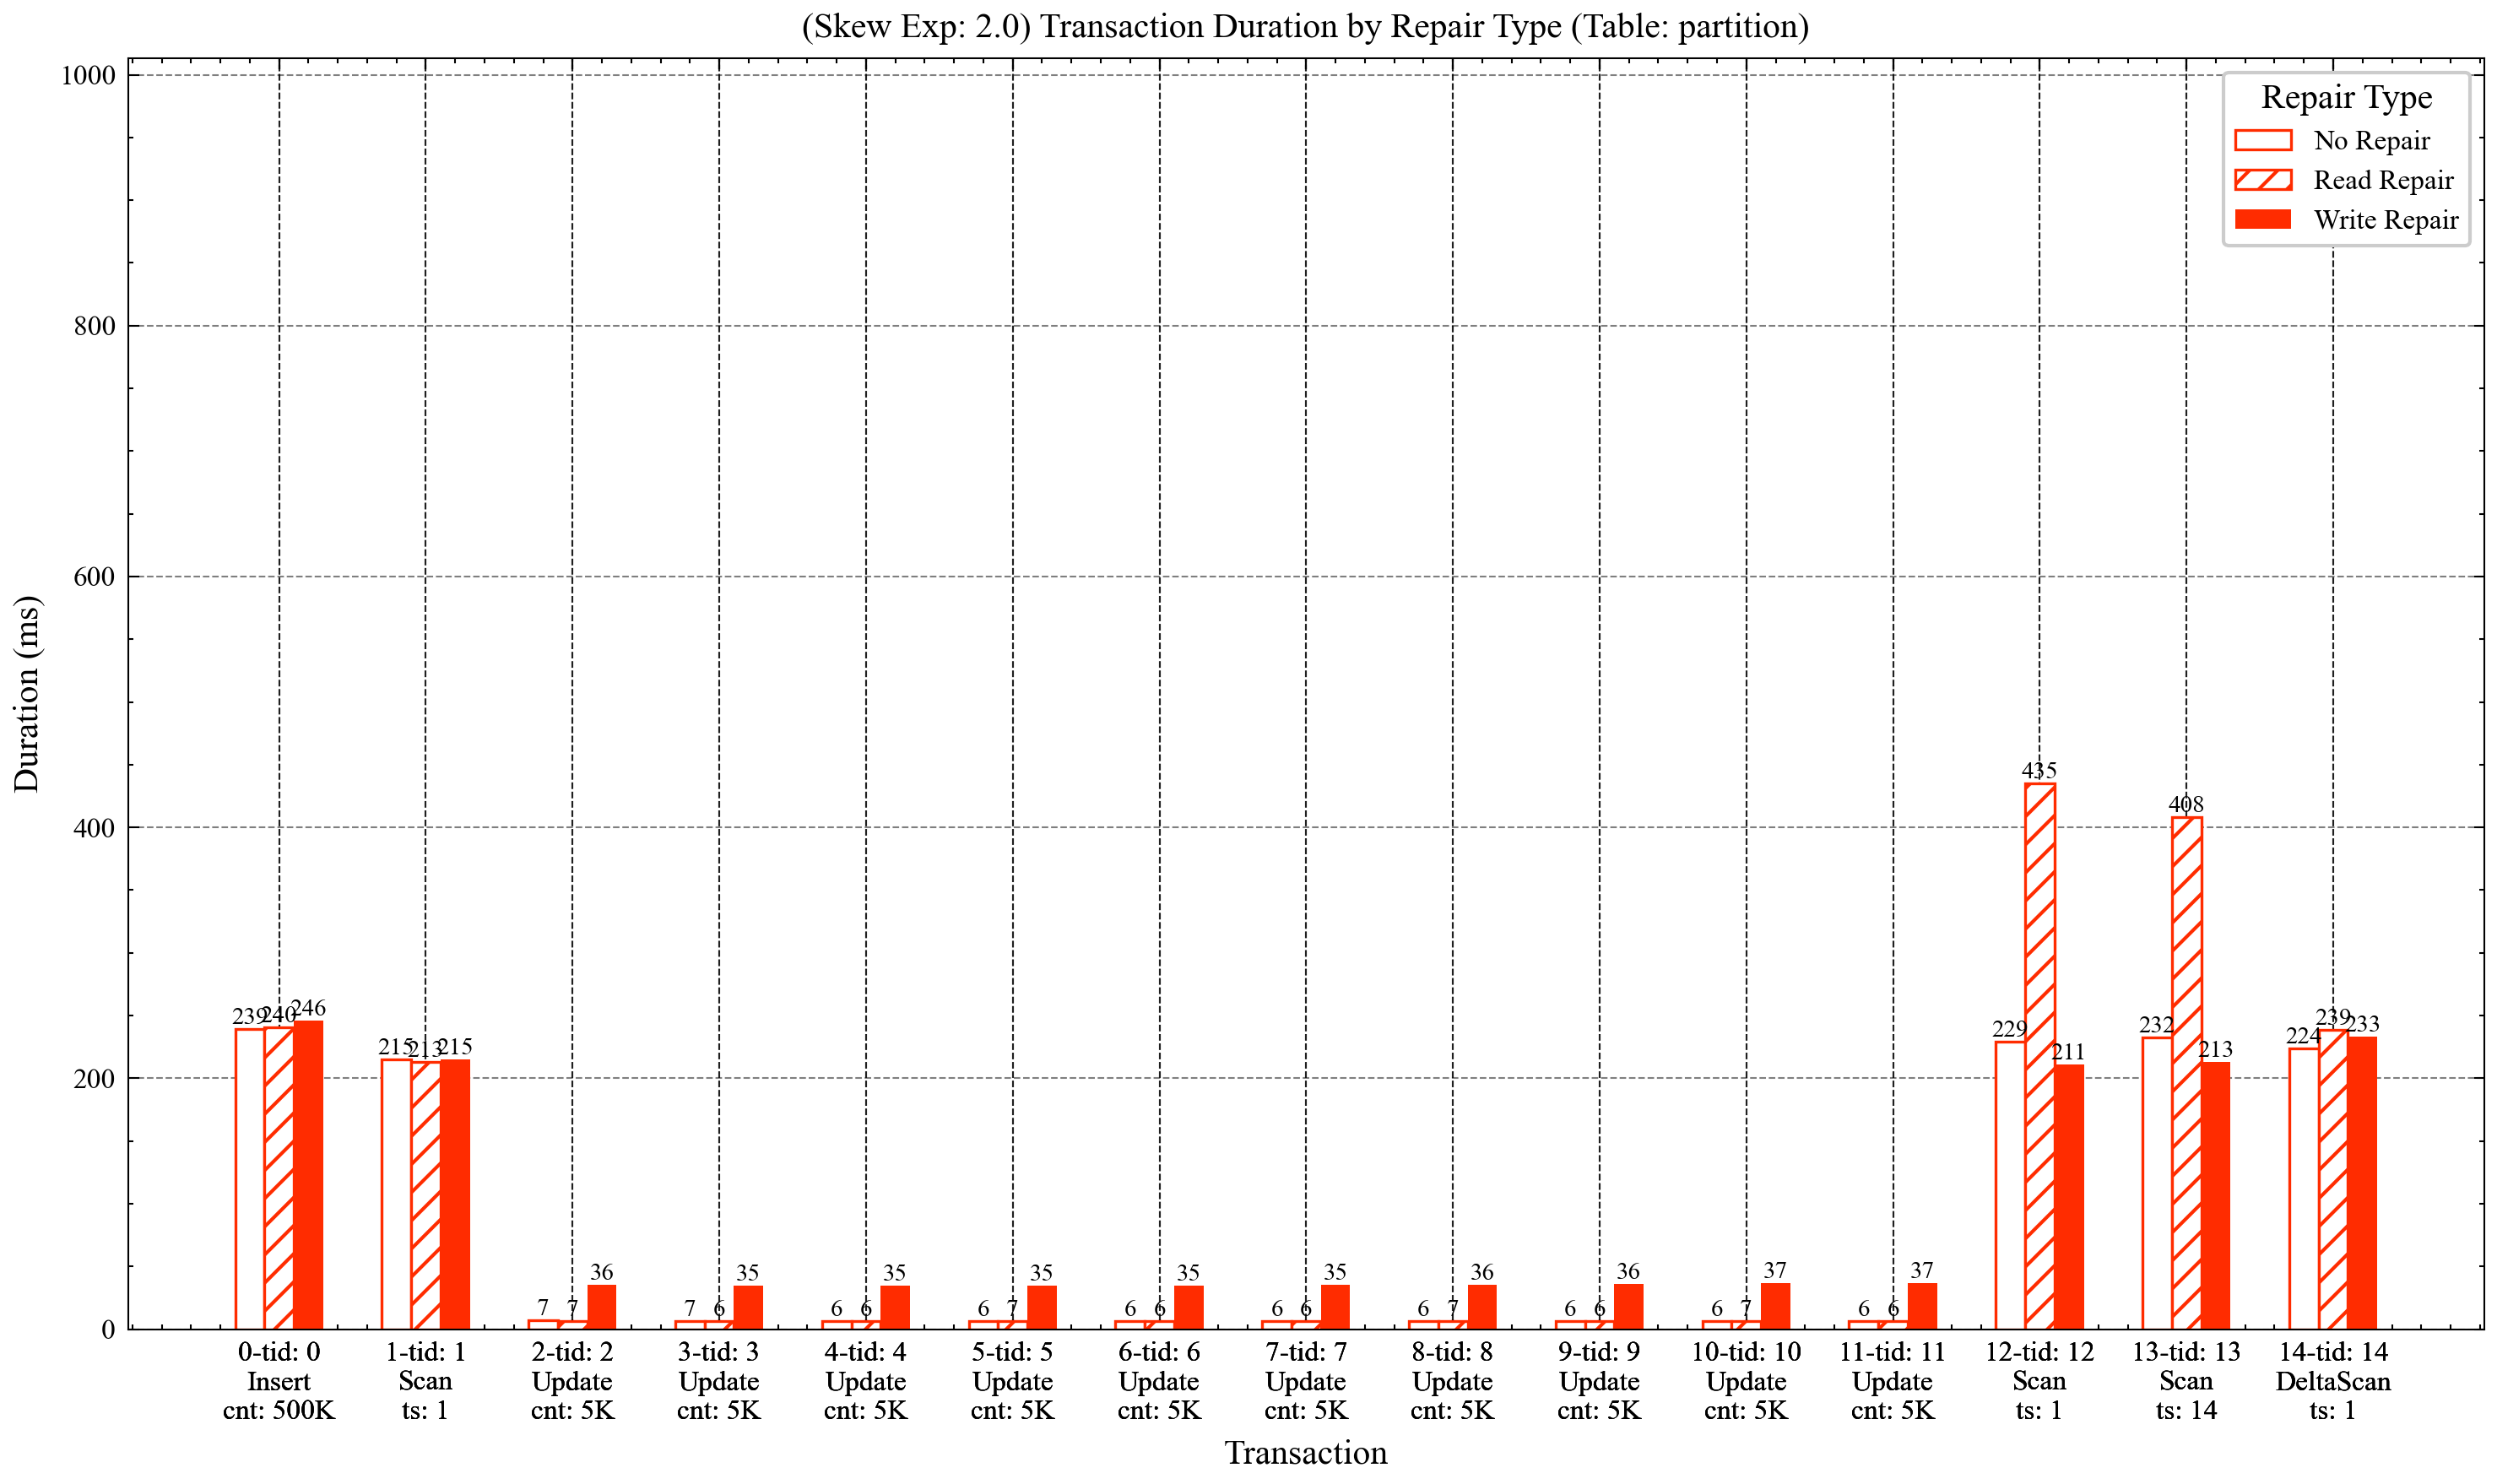

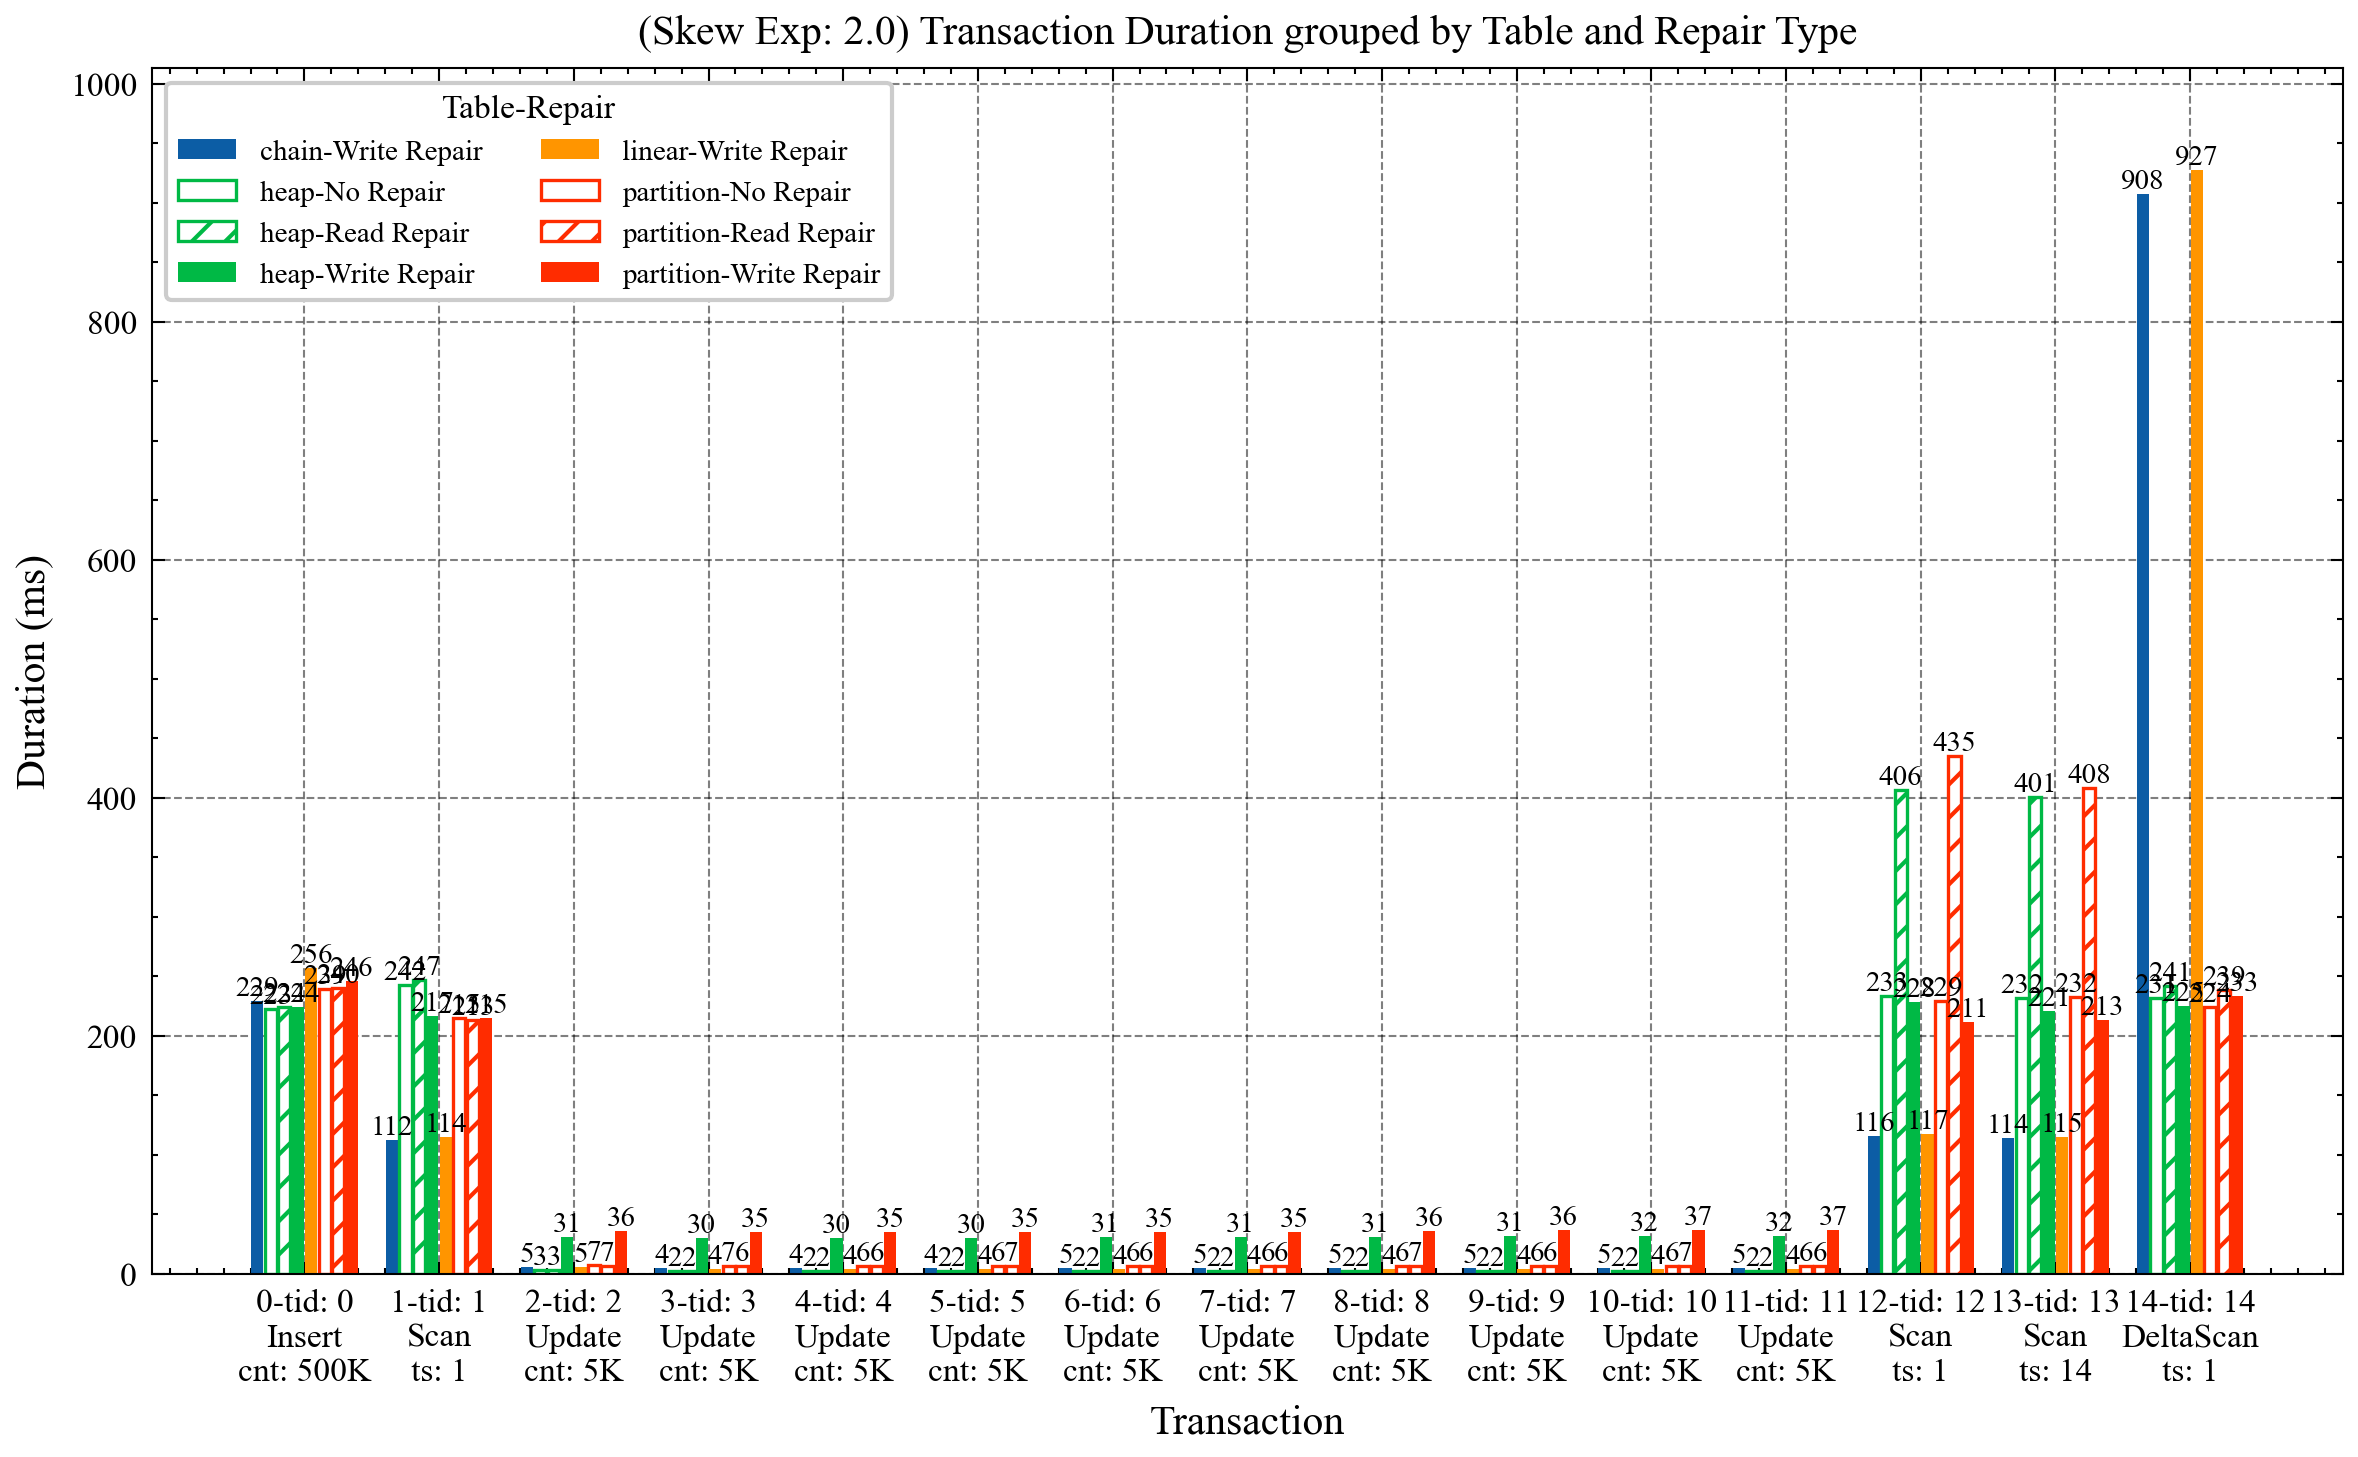

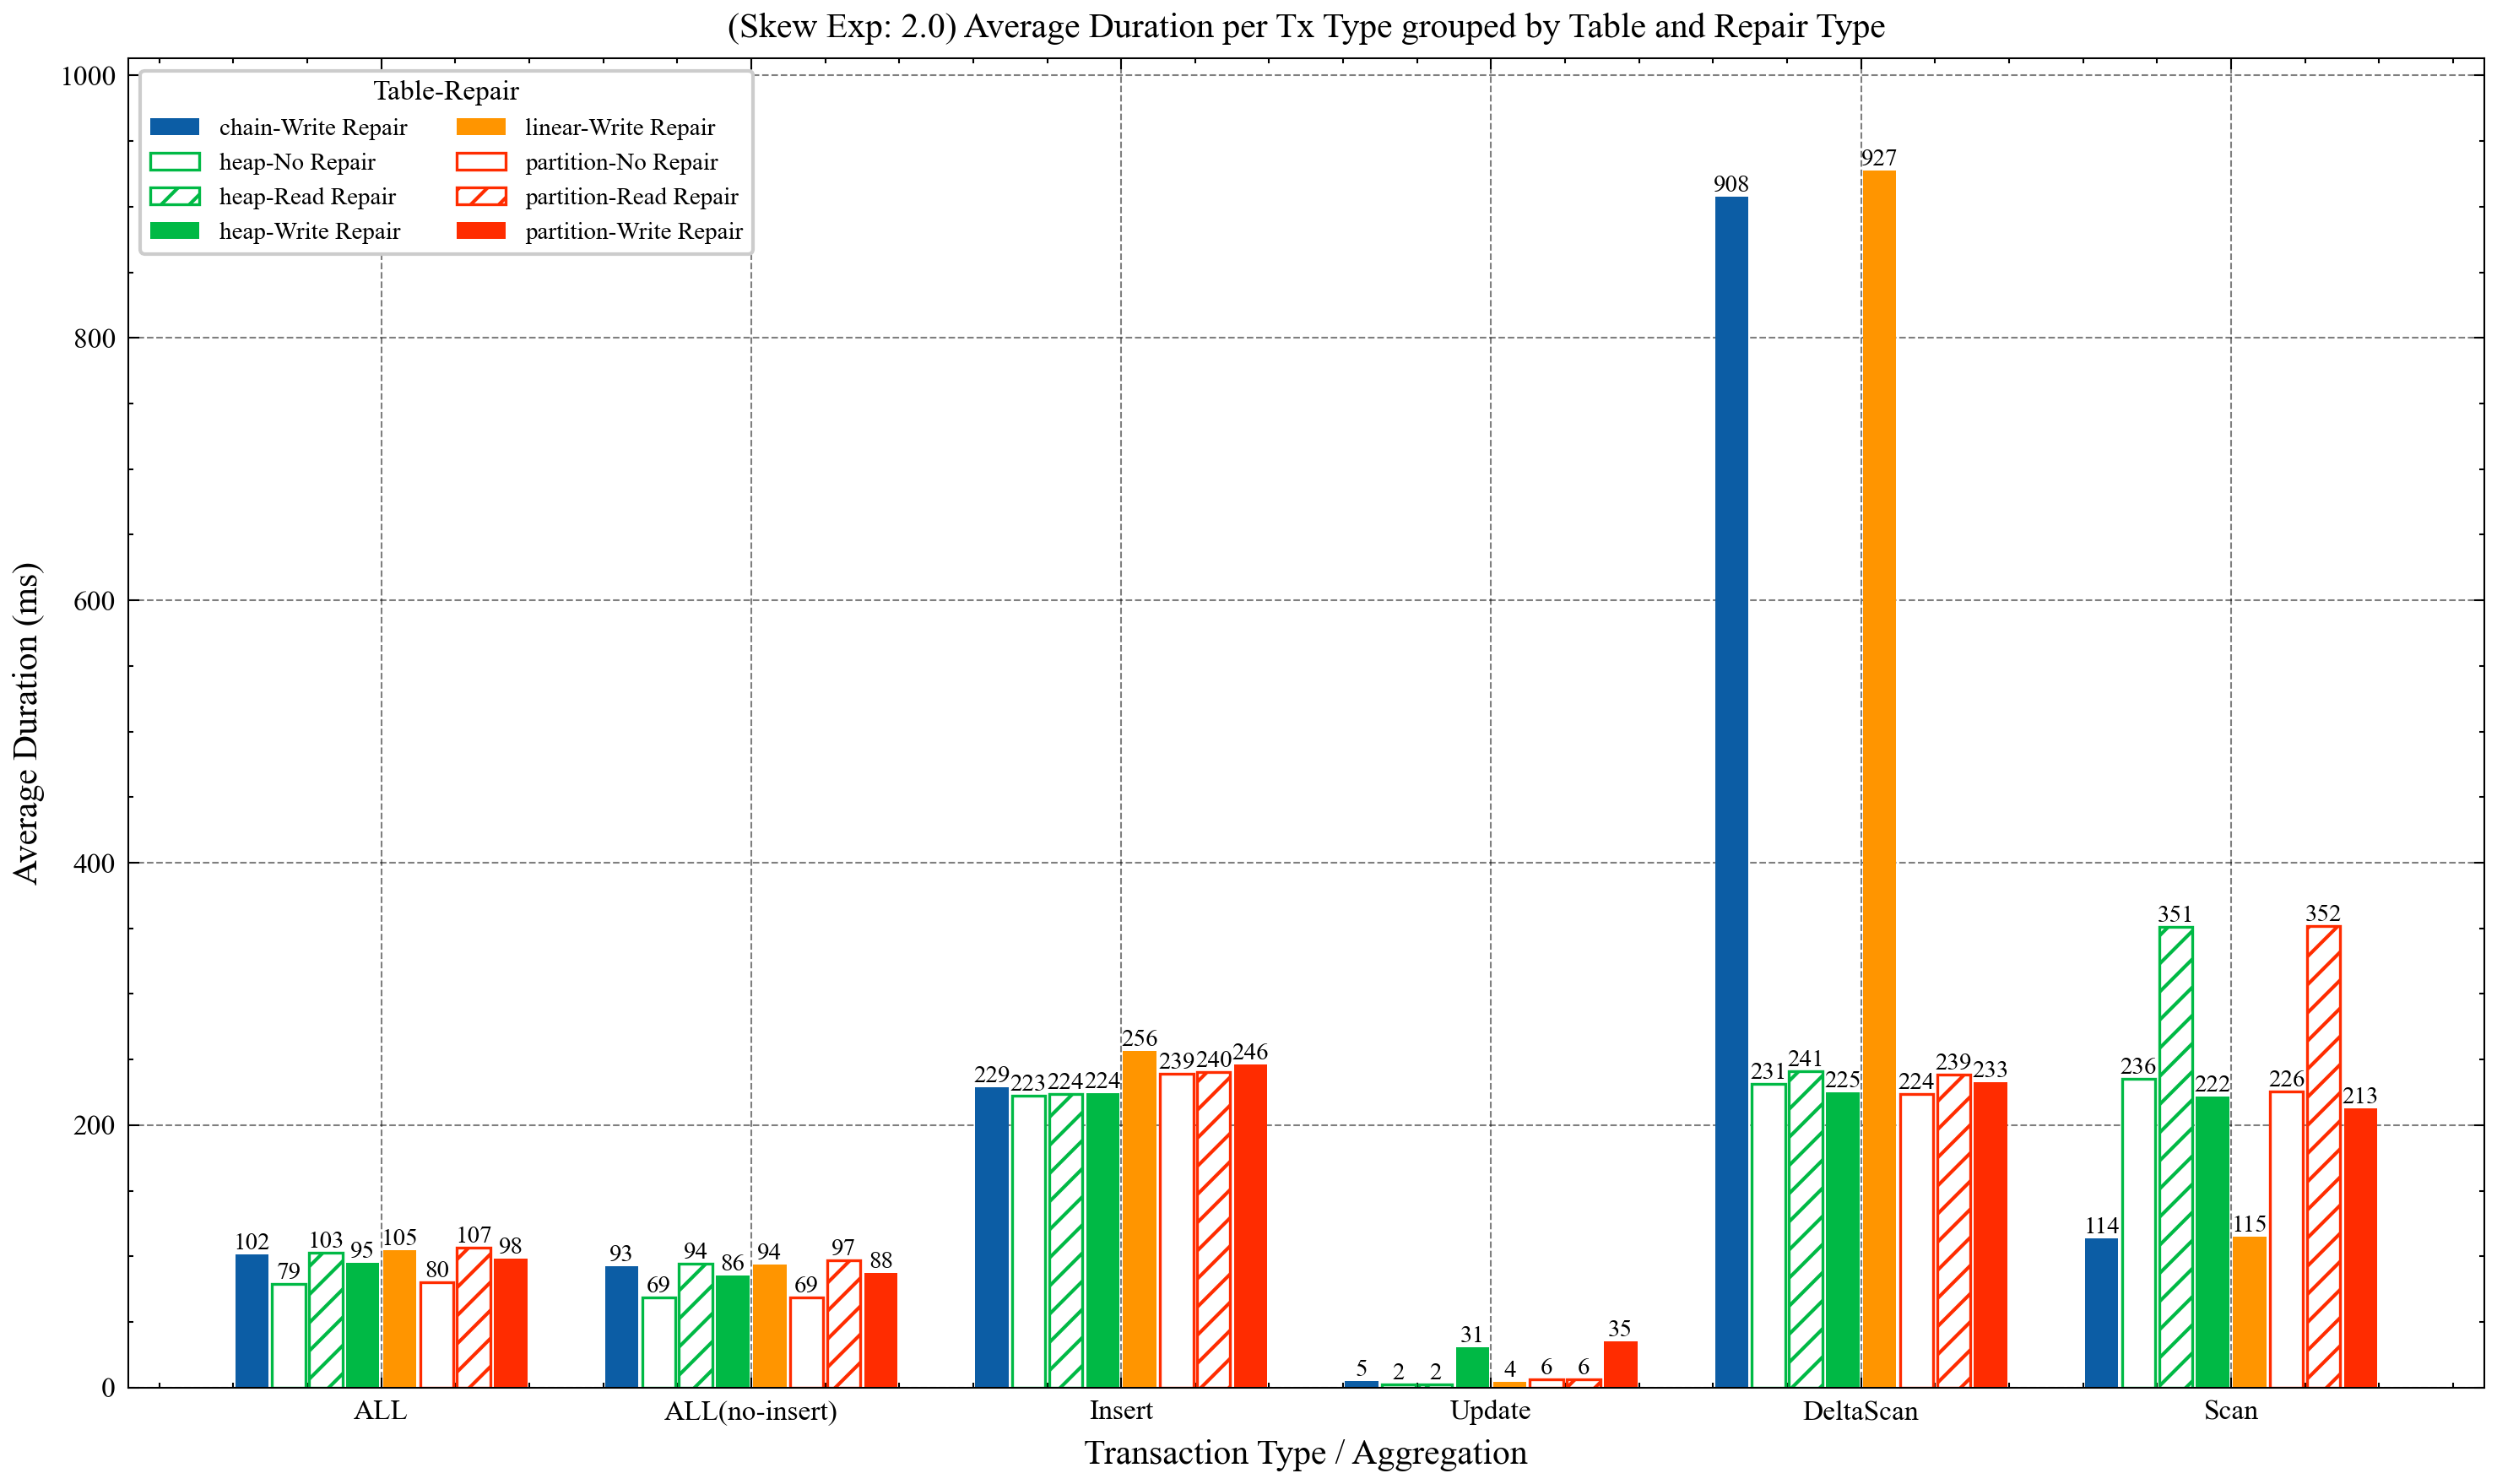

In [10]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Configuration
# ----------------------------------------

# Path to the join_repair binary
BIN = Path("../../../target/release/join_repair")
plt.style.use('../custom_plt_sytle.mplstyle')

# List of table types to test
TABLE_TYPES = ["linear", "chain", "heap", "partition"]

# Seed value
SEED = 15661183908140331744

# Repeat count for each table type
REPEAT = 1

# default values for update parameters
IS_SKEW_UPDATE = True
SKEW_EXP = 1.03
MANUAL_TXS = "u,0.1 scan,2 u,0.1 scan,4 u,0.1 scan,6 u,0.1 scan,8"

RUN_PARAMS = [
    # (skew_exp, MANUAL_TXS)
    (0.0, "scan,1 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 scan,1 scan,14 delta_scan,1"),
    (2.0, "scan,1 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 us,0.01 scan,1 scan,14 delta_scan,1"),
]

# Base CLI arguments (excluding table-type, which will be added separately)
BASE_ARGS = [
    "--row-count", "500k",
    "--join-key-size", "100",
    "--pkey-size", "100",
    "--value-size", "800",
    "--num-tx", "10",
    "--write-tx-ratio", "0.7",
    "--update-tx-ratio", "1.0",
    "--update-count-ratio", "0.1",
    "--insert-tx-ratio", "0.0",
    "--insert-count-ratio", "0.1",
    "--delete-tx-ratio", "0.0",
    "--delete-count-ratio", "0.1",
    "--get-tx-ratio", "0.0",
    "--get-count-ratio", "0.1",
    "--read-tx-ratio", "0.3",
    "--scan-key-tx-ratio", "0.0",
    "--scan-all-tx-ratio", "1.0",
    "--delta-scan-tx-ratio", "0.0",
    # "--num-join-keys", "..."   # Optional
    # "--recent-get-ratio", "..."  # Optional
    # "--bucket-num", "..."        # Optional
    "--seed", str(SEED),
]



# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
DEFAULT_BIN_NAME = "join_repair"
build_cmd = ["cargo", "build", "--release", "--bin", DEFAULT_BIN_NAME]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")



def gen_skew_title(is_skew, skew_exp) -> str:
    if is_skew:
        return f"(Skew Exp: {skew_exp})"
    else:
        return f"(NOT Skewed)"
def gen_manual_txs(
    update_cnt, 
    update_ratio_per_update,
    trailing_scan_cnt,
    is_trailing_delta_scan,
    is_delta_scan_intermediate,
    is_skew_update
) -> str:
    txs = []
    ts = 0
    for _ in range(0, update_cnt):
        if is_skew_update:
            txs.append(f"us,{update_ratio_per_update}")
        else:
            txs.append(f"u,{update_ratio_per_update}")
        
        if is_delta_scan_intermediate:
            txs.append(f"delta_scan,{ts}")
            ts += 1
        ts += 1

    for _ in range(0, trailing_scan_cnt):
        txs.append(f"scan,{ts}")
    ts += trailing_scan_cnt
    if is_trailing_delta_scan:
        txs.append(f"delta_scan,{0}")
    return ' '.join(txs)



# ----------------------------------------
# Function to parse the output
# ----------------------------------------

def parse_result(log_text, table_type):
    """
    Parse the stdout from join_repair into a structured DataFrame.
    """
    data = []
    repair_type = None
    no_repair_run_count = 0

    for line in log_text.splitlines():
        line = line.strip()

        # Detect repair type
        if line.startswith("No Repair"):
            repair_type = "No Repair"
            no_repair_run_count += 1
            continue
        elif line.startswith("Read Repair"):
            repair_type = "Read Repair"
            continue
        elif line.startswith("Write Repair"):
            repair_type = "Write Repair"
            continue
        
        # Match lines with timing information
        match = re.match(r'\[(.*?)\]\s+idx:\s+(\d+),\s+tx_id:\s+(\d+),\s+tx_type:\s+(\w+),\s+duration:\s+([0-9\.]+)(ms|s|µs),(.*)', line)
        if match and repair_type:
            if repair_type == "No Repair" and no_repair_run_count == 1:
                # Skip the first No Repair run (cache warm-up)
                continue

            _, idx, tx_id, tx_type, duration_value, duration_unit, rest = match.groups()

            # Normalize duration to milliseconds
            duration_value = float(duration_value)
            if duration_unit == 's':
                duration_ms = duration_value * 1000
            elif duration_unit == 'ms':
                duration_ms = duration_value
            elif duration_unit == 'µs':
                duration_ms = duration_value / 1000
            else:
                raise ValueError(f"Unknown time unit: {duration_unit}")

            # Parse additional information (count or read_ts)
            count = None
            read_ts = None
            if 'Insert count' in rest or 'Update count' in rest:
                count_match = re.search(r'count:\s*(\d+)', rest)
                if count_match:
                    count = int(count_match.group(1))
            if 'read_ts' in rest:
                read_ts_match = re.search(r'read_ts:\s*(\d+)', rest)
                if read_ts_match:
                    read_ts = int(read_ts_match.group(1))

            data.append({
                'table_type': table_type,
                'repair_type': repair_type,
                'idx': int(idx),
                'tx_id': int(tx_id),
                'tx_type': tx_type,
                'duration_ms': duration_ms,
                'count': count,
                'read_ts': read_ts,
            })

    return pd.DataFrame(data)

# ----------------------------------------
# Function to run the binary and collect data
# ----------------------------------------

def run_and_collect(bin_path, table_types, base_args):
    """
    Execute join_repair binary for each table type multiple times and average the results.
    """
    all_dfs = []

    for table_type in table_types:
        print(f"Running for table_type={table_type} with {REPEAT} repeats...")
        dfs = []

        for trial in range(REPEAT):
            print(f"  - Trial {trial+1}/{REPEAT}")

            args = [str(bin_path)] + base_args + ["--table-type", table_type]

            result = subprocess.run(
                args,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True
            )

            if result.returncode != 0:
                print(f"Error running join_repair for {table_type} (trial {trial+1}):")
                print(result.stderr)
                continue
            
            df = parse_result(result.stdout, table_type)
            dfs.append(df)

        if dfs:
            # Concatenate all repeated runs
            df_all = pd.concat(dfs, ignore_index=True)

            # Group by (idx, tx_id, tx_type, repair_type, table_type) and average duration_ms
            df_avg = (
                df_all
                .groupby(['idx', 'tx_id', 'tx_type', 'repair_type', 'table_type'], as_index=False)
                .agg({
                    'duration_ms': 'mean',
                    'count': 'first',
                    'read_ts': 'first'
                })
            )

            all_dfs.append(df_avg)

    if all_dfs:
        final_df = pd.concat(all_dfs, ignore_index=True)
        return final_df
    else:
        return pd.DataFrame()

# ----------------------------------------
# Function to plot the results
# ----------------------------------------
def draw_bar_labels(ax, x_positions, heights, font_size=7):
    for x, y in zip(x_positions, heights):
        if y > 0:  
            ax.text(
                x, 
                y, 
                f"{y:.0f}", 
                ha='center', 
                va='bottom', 
                fontsize=font_size
            )

def prepare_plot_data(df):
    prop_cycler = plt.rcParams['axes.prop_cycle']
    colors = prop_cycler.by_key()['color']

    table_types = sorted(df['table_type'].unique())
    color_map = {table_type: colors[i % len(colors)] for i, table_type in enumerate(table_types)}

    repair_hatches = {
        "Write Repair": "",
        "Read Repair": "///",
        "No Repair": "",
    }
    repair_types = ["No Repair", "Read Repair", "Write Repair"]

    unique_idx = sorted(df['idx'].unique())

    x_labels = []
    for idx in unique_idx:
        row = df[df['idx'] == idx].iloc[0]
        optional = ""
        if row['tx_type'] in ["Insert", "Update", "Delete", "Get"] and pd.notnull(row['count']):
            count = int(row['count'])
            if count >= 1_000_000:
                value = count / 1_000_000
                count_str = f"{value:.1f}".rstrip('0').rstrip('.') + "M"
            elif count >= 1_000:
                value = count / 1_000
                count_str = f"{value:.1f}".rstrip('0').rstrip('.') + "K"
            else:
                count_str = str(count)
            optional = f"cnt: {count_str}"
        elif row['tx_type'] in ["ScanKey", "Scan", "DeltaScan"] and pd.notnull(row['read_ts']):
            optional = f"ts: {int(row['read_ts'])}"
        label = f"{idx}-tid: {row['tx_id']}\n{row['tx_type']}\n{optional}"
        x_labels.append(label)

    return color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels

def prepare_bar_style(repair_type, table_type, color_map, repair_hatches):
    if repair_type == "Write Repair":
        return {
            'facecolor': color_map[table_type],
            'edgecolor': color_map[table_type],
            'hatch': '',
            'linewidth': 0
        }
    else:
        return {
            'facecolor': 'white',
            'edgecolor': color_map[table_type],
            'hatch': repair_hatches.get(repair_type, ''),
            'linewidth': 0.8
        }

def plot_result(df, max_y=None):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels = prepare_plot_data(df)

    for table_type in table_types:
        fig, ax = plt.subplots(figsize=(10, 6))

        width = 0.2
        offsets = [-width, 0, width]

        df_table = df[df['table_type'] == table_type].sort_values('idx')

        for i, repair_type in enumerate(repair_types):
            if table_type in ["chain", "linear"] and repair_type != "Write Repair":
                continue # chain and linear only support Write Repair
            df_repair = df_table[df_table['repair_type'] == repair_type]

            style = prepare_bar_style(repair_type, table_type, color_map, repair_hatches)

            ax.bar(
                df_repair['idx'] + offsets[i],
                df_repair['duration_ms'],
                width=width,
                label=repair_type,
                **style
            )

            draw_bar_labels(ax, df_repair['idx'] + offsets[i], df_repair['duration_ms'])

        if max_y is not None:
            ax.set_ylim(0, max_y)

        ax.set_xticks(df_table['idx'])
        ax.set_xticklabels([x_labels[unique_idx.index(idx)] for idx in df_table['idx']], rotation=0, fontsize=8, ha='center')

        ax.set_xlabel('Transaction')
        ax.set_ylabel('Duration (ms)')
        ax.set_title(f"{gen_skew_title(IS_SKEW_UPDATE, SKEW_EXP)} Transaction Duration by Repair Type (Table: {table_type})")

        ax.legend(title="Repair Type", loc="best")
        plt.tight_layout()
        plt.show()

def plot_all(df, max_y=None):
    """
    Plot each transaction (idx) individually without summary bars.
    """
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels = prepare_plot_data(df)

    fig, ax = plt.subplots(figsize=(max(8, len(unique_idx) * 0.5), 5))

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "linear"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    num_bars_per_group = len(groups)
    group_width = 0.8
    bar_width = group_width / num_bars_per_group

    idx_to_pos = {idx: pos for pos, idx in enumerate(unique_idx)}

    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "linear"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        x_positions = []
        durations = []

        for idx in unique_idx:
            x_pos = idx_to_pos[idx] + (i - num_bars_per_group/2) * bar_width + bar_width/2
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            x_positions.append(x_pos)
            durations.append(duration)

        style = prepare_bar_style(repair_type, table_type, color_map, repair_hatches)

        ax.bar(
            x_positions,
            durations,
            width=bar_width * 0.9,
            label=f"{table_type}-{repair_type}",
            **style
        )

        draw_bar_labels(ax, x_positions, durations)

    if max_y is not None:
        ax.set_ylim(0, max_y)

    ax.set_xticks(range(len(unique_idx)))
    ax.set_xticklabels(x_labels, rotation=0, fontsize=8, ha='center')

    ax.set_xlabel('Transaction')
    ax.set_ylabel('Duration (ms)')
    ax.set_title(f'{gen_skew_title(IS_SKEW_UPDATE, SKEW_EXP)} Transaction Duration grouped by Table and Repair Type')

    plt.grid(True, axis='y')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Table-Repair", fontsize=7, title_fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()

def plot_avg_by_type(df, max_y=None):
    """
    Plot average duration grouped by tx_type and repair/table types.
    """
    color_map, repair_hatches, repair_types, table_types, _, _ = prepare_plot_data(df)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Define groups
    tx_type_groups = ["ALL", "ALL(no-insert)", "Insert", "Update", "DeltaScan", "Scan"]
    x_labels = tx_type_groups

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "linear"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    num_bars_per_group = len(groups)
    group_width = 0.8
    bar_width = group_width / num_bars_per_group

    idx_to_pos = {idx: pos for pos, idx in enumerate(range(len(tx_type_groups)))}

    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "linear"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        durations = []

        # ALL tx average
        all_vals = df_group['duration_ms'].values
        avg_all = all_vals.mean() if len(all_vals) > 0 else 0
        durations.append(avg_all)

        # ALL(no-insert) average
        non_insert_vals = df_group[df_group['tx_type'] != "Insert"]['duration_ms'].values
        avg_no_insert = non_insert_vals.mean() if len(non_insert_vals) > 0 else 0
        durations.append(avg_no_insert)

        # Insert only average
        insert_vals = df_group[df_group['tx_type'] == "Insert"]['duration_ms'].values
        avg_insert = insert_vals.mean() if len(insert_vals) > 0 else 0
        durations.append(avg_insert)

        # Update only average
        update_vals = df_group[df_group['tx_type'] == "Update"]['duration_ms'].values
        avg_update = update_vals.mean() if len(update_vals) > 0 else 0
        durations.append(avg_update)

        # Scan only average
        scan_vals = df_group[df_group['tx_type'] == "DeltaScan"]['duration_ms'].values
        avg_scan = scan_vals.mean() if len(scan_vals) > 0 else 0
        durations.append(avg_scan)

        # Scan only average
        scan_vals = df_group[df_group['tx_type'] == "Scan"]['duration_ms'].values
        avg_scan = scan_vals.mean() if len(scan_vals) > 0 else 0
        durations.append(avg_scan)

        # x positions
        x_positions = []
        for idx in range(len(tx_type_groups)):
            x_pos = idx + (i - num_bars_per_group/2) * bar_width + bar_width/2
            x_positions.append(x_pos)

        style = prepare_bar_style(repair_type, table_type, color_map, repair_hatches)

        # print(x_positions)
        # print(durations)
        ax.bar(
            x_positions,
            durations,
            width=bar_width * 0.9,
            label=f"{table_type}-{repair_type}",
            **style
        )

        draw_bar_labels(ax, x_positions, durations)

    if max_y is not None:
        ax.set_ylim(0, max_y)

    ax.set_xticks(range(len(tx_type_groups)))
    ax.set_xticklabels(x_labels, rotation=0, fontsize=8, ha='center')

    ax.set_xlabel('Transaction Type / Aggregation')
    ax.set_ylabel('Average Duration (ms)')
    ax.set_title(f'{gen_skew_title(IS_SKEW_UPDATE, SKEW_EXP)} Average Duration per Tx Type grouped by Table and Repair Type')

    plt.grid(True, axis='y')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Table-Repair", fontsize=7, title_fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()

# ----------------------------------------
# Main execution
# ----------------------------------------


# (skew_exp, MANUAL_TXS)
for (skew_exp, MANUAL_TXS) in RUN_PARAMS:
    SKEW_EXP = skew_exp
    IS_SKEW_UPDATE = True if abs(skew_exp) > 1e-10 else False
    NEW_ARGS = BASE_ARGS.copy()
    if IS_SKEW_UPDATE:
        NEW_ARGS += ["--skew-exponent", str(SKEW_EXP)]

    print(f"MANUAL_TXS: {MANUAL_TXS}")
    NEW_ARGS += ["--manual-txs", MANUAL_TXS]

    # Run experiments and collect results
    df = run_and_collect(BIN, TABLE_TYPES, NEW_ARGS)

    # Display the resulting DataFrame
    display(df)

    max_y = df['duration_ms'].max() * 1.05

    # Plot per table type
    plot_result(df, max_y=max_y)

    # Plot one combined figure
    plot_all(df, max_y=max_y)

    # Plot average durations per tx_type
    plot_avg_by_type(df, max_y=max_y)
